<a href="https://colab.research.google.com/github/marwaguiniche/myproject/blob/main/P2M_LSTM_v4_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Importation du dataset netoyée**

In [ ]:
import pandas as pd
from google.colab import drive

# ── Montage de Google Drive ───────────────────────────────────────
drive.mount('/content/drive')

# ── Chemin du fichier sur Drive ───────────────────────────────────
# Modifier selon l'emplacement exact de ton fichier dans Drive
chemin_fichier = '/content/drive/MyDrive/Dataset_Clean_ML.csv'
# Exemples si ton fichier est dans un sous-dossier :
# chemin_fichier = '/content/drive/MyDrive/OMC/Dataset_Clean_ML.csv'
# chemin_fichier = '/content/drive/MyDrive/Projet_P2M/Dataset_Clean_ML.csv'

# ── Chargement ────────────────────────────────────────────────────
df_clean = pd.read_csv(chemin_fichier, sep=';')

print(f"Mon fichier contient {df_clean.shape[0]} lignes et {df_clean.shape[1]} colonnes.")
display(df_clean.head(10))

Mounted at /content/drive
Mon fichier contient 1959516 lignes et 14 colonnes.


,Time,eNodeB_Name,Cell_Name,eNodeB_Function_Name,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,KPI_HOSR_InterFreq,KPI_HOSR_InterRAT,Cell_Availability,CSFB_SR
0,2025-06-01 00:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.968198,0.000000,99.967711,11.791251,1.327820,100.000000,100.0,100.0,100.0,100.0
1,2025-06-01 01:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.801980,0.000000,99.808734,14.219384,2.090457,100.000000,100.0,100.0,100.0,100.0
2,2025-06-01 02:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.911894,0.000000,99.953661,19.757798,4.220755,100.000000,100.0,100.0,100.0,100.0
3,2025-06-01 03:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.000000,100.000000,20.931697,2.357093,100.000000,100.0,100.0,100.0,100.0
4,2025-06-01 04:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.000000,100.000000,15.794695,0.948091,100.000000,100.0,100.0,100.0,100.0
5,2025-06-01 05:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.000000,99.950568,15.891576,4.197642,100.000000,100.0,100.0,100.0,100.0
6,2025-06-01 06:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.926776,0.000000,99.973822,12.796559,2.514590,100.000000,100.0,100.0,100.0,100.0
7,2025-06-01 07:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.893603,0.014251,99.971579,10.437760,1.720894,97.368421,100.0,100.0,100.0,100.0
8,2025-06-01 08:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.990767,0.000000,99.960384,9.945187,1.818623,98.550725,100.0,100.0,100.0,100.0
9,2025-06-01 09:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.944639,0.010083,99.919257,9.884786,1.820692,98.484848,100.0,100.0,100.0,100.0


**Observation d'une cellule**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On choisit la cellule à observer (celle de ta capture d'écran)
nom_cellule = "ABECOUTA_e1"

# 2. On filtre le dataset pour ne garder que cette cellule
df_cellule = df_clean[df_clean['Cell_Name'] == nom_cellule]

# 3. On trace la courbe d'évolution du Trafic Descendant (DL)
plt.figure(figsize=(15, 6))
plt.plot(df_cellule['Time'], df_cellule['KPI_Thrp_DL_Mbps'], marker='o', linestyle='-', color='#1f77b4')

plt.title(f"Évolution du Débit 4G (DL Mbps) pour la cellule : {nom_cellule}", fontsize=14, fontweight='bold')
plt.xlabel("Heure", fontsize=12)
plt.ylabel("Trafic Descendant (Mbps)", fontsize=12)
plt.xticks(rotation=45) # Penche les dates pour mieux les lire
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

**Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

# ── Variables colonnes ────────────────────────────────────────────
TIME_COL = 'Time'
CELL_COL = 'Cell_Name'

# ─────────────────────────────────────────────────────────────────
# PRÉTRAITEMENT COMPLET DU DATASET
# ─────────────────────────────────────────────────────────────────
def preprocess_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prétraitement complet du dataset 1.96M lignes.

    Opérations appliquées (dans l'ordre) :
    ────────────────────────────────────────
    1. Validation des bornes physiques des KPI (clamping)
    2. Détection et flagging des outliers statistiques (IQR × 3)
    3. Ré-indexation horaire par cellule + interpolation des gaps
    4. Feature engineering temporel (sin/cos cyclique)

    Note sur la performance :
    → Opérations vectorisées pandas (pas de boucle ligne par ligne)
    → Sur 1.96M lignes : ~15-30 secondes selon le CPU Colab
    """
    print("Prétraitement du dataset...")
    t0 = time.time()
    df = df.copy()

    # ── 1. Validation bornes physiques ───────────────────────────
    print("  [1/4] Validation des bornes physiques...")
    bounds = {
        'KPI_RRC_SR':        (0.0, 100.0),
        'KPI_DCR':           (0.0, 100.0),
        'KPI_ERAB_SR':       (0.0, 100.0),
        'KPI_Thrp_DL_Mbps':  (0.0, None),
        'KPI_Thrp_UL_Mbps':  (0.0, None),
        'KPI_HOSR':          (0.0, 100.0),
        'KPI_HOSR_InterFreq':(0.0, 100.0),
        'KPI_HOSR_InterRAT': (0.0, 100.0),
        'Cell_Availability': (0.0, 100.0),
        'CSFB_SR':           (0.0, 100.0),
    }
    n_clamped = 0
    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        if lo is not None:
            mask = df[col] < lo
            n_clamped += mask.sum()
            df.loc[mask, col] = lo
        if hi is not None:
            mask = df[col] > hi
            n_clamped += mask.sum()
            df.loc[mask, col] = hi
    print(f"     → {n_clamped:,} valeurs clampées aux bornes physiques")

    # ── 2. Détection outliers (IQR × 3) ──────────────────────────
    print("  [2/4] Détection des outliers statistiques...")
    outlier_kpis = ['KPI_DCR', 'KPI_HOSR', 'KPI_Thrp_DL_Mbps']
    n_outliers = 0
    for col in outlier_kpis:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)
        df[f'{col}_outlier'] = mask.astype('int8')
        n_outliers += mask.sum()
    print(f"     → {n_outliers:,} outliers flaggés (IQR × 3) "
          f"sur {', '.join(outlier_kpis)}")

    # ── 3. Gaps temporels : ré-index + interpolation ──────────────
    print("  [3/4] Gestion des gaps temporels (interpolation)...")
    kpi_cols = [c for c in df.columns
                if c.startswith('KPI_') or c in ['Cell_Availability', 'CSFB_SR']]

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
    df.dropna(subset=[TIME_COL], inplace=True)

    df_sorted  = df.sort_values([CELL_COL, TIME_COL])
    time_diffs = df_sorted.groupby(CELL_COL)[TIME_COL].diff()
    n_gaps     = (time_diffs > pd.Timedelta('1h')).sum()
    max_gap    = time_diffs.max()
    print(f"     → Gaps détectés : {n_gaps:,} (gap max : {max_gap})")

    df = df.sort_values([CELL_COL, TIME_COL]).reset_index(drop=True)
    for col in kpi_cols:
        df[col] = (df.groupby(CELL_COL)[col]
                   .transform(lambda x: x.interpolate(method='linear', limit=3)))

    n_remaining_nan = df[kpi_cols].isnull().sum().sum()
    print(f"     → NaN résiduels après interpolation : {n_remaining_nan:,}")
    if n_remaining_nan > 0:
        df[kpi_cols] = df[kpi_cols].ffill().bfill()
        print(f"     → Forward/backward fill appliqué sur les NaN résiduels")

    # ── 4. Feature Engineering temporel ──────────────────────────
    print("  [4/4] Feature engineering temporel...")
    hour = df[TIME_COL].dt.hour.astype('float32')
    dow  = df[TIME_COL].dt.dayofweek.astype('float32')
    doy  = df[TIME_COL].dt.dayofyear.astype('float32')

    # Encodage cyclique sin/cos
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24).astype('float32')
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype('float32')
    df['dow_sin']  = np.sin(2 * np.pi * dow  / 7).astype('float32')
    df['dow_cos']  = np.cos(2 * np.pi * dow  / 7).astype('float32')
    df['doy_sin']  = np.sin(2 * np.pi * doy  / 365).astype('float32')
    df['doy_cos']  = np.cos(2 * np.pi * doy  / 365).astype('float32')

    # Features brutes (compatibilité avec les cellules LSTM suivantes)
    df['Hour']       = hour.astype('int8')   # ← nom Hour conservé (utilisé plus bas)
    df['DayOfWeek']  = dow.astype('int8')    # ← nom DayOfWeek conservé
    df['is_night']   = ((hour >= 0) & (hour <= 6)).astype('int8')
    df['is_peak']    = ((hour >= 7) & (hour <= 21)).astype('int8')

    gc.collect()
    elapsed = time.time() - t0
    print(f"\n  ✅ Prétraitement terminé en {elapsed:.1f}s")
    print(f"     Shape finale : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"     RAM          : {df.memory_usage(deep=True).sum()/1024**2:.1f} Mo")

    return df


# ── Exécution ─────────────────────────────────────────────────────
df_ml = preprocess_dataset(df_clean)

print(f"\n  Nouvelles colonnes temporelles ajoutées :")
new_cols = ['hour_sin','hour_cos','dow_sin','dow_cos',
             'Hour','DayOfWeek','is_night','is_peak']
print(f"  {[c for c in new_cols if c in df_ml.columns]}")

# ── Reconstruction de X et scaler (attendus par les cellules LSTM) ─
# On garde les mêmes colonnes numériques qu'avant
colonnes_a_retirer = ['Time', 'eNodeB_Name', 'Cell_Name', 'eNodeB_Function_Name']
# Exclure aussi les colonnes outlier (int8, non numériques pour le scaler)
outlier_cols = [c for c in df_ml.columns if c.endswith('_outlier')]
X = df_ml.drop(columns=[c for c in colonnes_a_retirer + outlier_cols
                          if c in df_ml.columns])

scaler = StandardScaler()
X_scaled_matrix = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_matrix, columns=X.columns)

print(f"\n  ✅ X_scaled prêt : {X_scaled.shape}")
print(f"  ✅ scaler prêt   : StandardScaler fitté sur {X_scaled.shape[1]} features")
print("\nAperçu de df_ml (5 premières lignes) :")
display(df_ml.head())

# ── 5. Feature différentielle Delta_ERAB ─────────────────────
# Mesure la dégradation propre au bearer vs la qualité radio
# = 0      : normal (ERAB suit exactement RRC)
# < -5%    : problème cœur réseau (SGW/S1-U)
# même chute que RRC : problème radio pur
if 'KPI_ERAB_SR' in df_ml.columns and 'KPI_RRC_SR' in df_ml.columns:
    df_ml['Delta_ERAB'] = df_ml['KPI_ERAB_SR'] - df_ml['KPI_RRC_SR']
    print("  ✅ Feature Delta_ERAB créée (KPI_ERAB_SR - KPI_RRC_SR)")


Prétraitement du dataset...
  [1/4] Validation des bornes physiques...
     → 14 valeurs clampées aux bornes physiques
  [2/4] Détection des outliers statistiques...
     → 593,483 outliers flaggés (IQR × 3) sur KPI_DCR, KPI_HOSR, KPI_Thrp_DL_Mbps
  [3/4] Gestion des gaps temporels (interpolation)...
     → Gaps détectés : 81,303 (gap max : 1 days 08:00:00)
     → NaN résiduels après interpolation : 0
  [4/4] Feature engineering temporel...

  ✅ Prétraitement terminé en 78.6s
     Shape finale : 1,959,516 lignes × 27 colonnes
     RAM          : 573.8 Mo

  Nouvelles colonnes temporelles ajoutées :
  ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'Hour', 'DayOfWeek', 'is_night', 'is_peak']

  ✅ X_scaled prêt : (1959516, 20)
  ✅ scaler prêt   : StandardScaler fitté sur 20 features

Aperçu de df_ml (5 premières lignes) :


,Time,eNodeB_Name,Cell_Name,eNodeB_Function_Name,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,...,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,Hour,DayOfWeek,is_night,is_peak
0,2025-06-01 00:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.968198,0.0,99.967711,11.791251,1.327820,100.0,...,0.000000,1.000000,-0.781832,0.62349,0.501242,-0.865307,0,6,1,0
1,2025-06-01 01:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.801980,0.0,99.808734,14.219384,2.090457,100.0,...,0.258819,0.965926,-0.781832,0.62349,0.501242,-0.865307,1,6,1,0
2,2025-06-01 02:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,99.911894,0.0,99.953661,19.757798,4.220755,100.0,...,0.500000,0.866025,-0.781832,0.62349,0.501242,-0.865307,2,6,1,0
3,2025-06-01 03:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.0,100.000000,20.931697,2.357093,100.0,...,0.707107,0.707107,-0.781832,0.62349,0.501242,-0.865307,3,6,1,0
4,2025-06-01 04:00:00,ABECOUTA,ABECOUTA_e1,ABECOUTA_L,100.000000,0.0,100.000000,15.794695,0.948091,100.0,...,0.866025,0.500000,-0.781832,0.62349,0.501242,-0.865307,4,6,1,0


  ✅ Feature Delta_ERAB créée (KPI_ERAB_SR - KPI_RRC_SR)


**Le modéle Isolation forest pour détecter les anomalies**

In [ ]:
from sklearn.ensemble import IsolationForest

print("⏳ Entraînement de l'Isolation Forest en cours... (Cela peut prendre environ 1 à 2 minutes)")

modele_if = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

predictions = modele_if.fit_predict(X_scaled)

df_ml['Statut_Reseau'] = ['Anomalie 🚨' if x == -1 else 'Normal ✅' for x in predictions]

print("\n✅ Analyse terminée ! Voici le bilan de santé du réseau :")
print(df_ml['Statut_Reseau'].value_counts())

⏳ Entraînement de l'Isolation Forest en cours... (Cela peut prendre environ 1 à 2 minutes)

✅ Analyse terminée ! Voici le bilan de santé du réseau :
Statut_Reseau
Normal ✅      1939920
Anomalie 🚨      19596
Name: count, dtype: int64


### 💾 Sauvegarde Isolation Forest

In [ ]:
import joblib
import os

# ══════════════════════════════════════════════════════════════
# 💾 SAUVEGARDE — Isolation Forest
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Sauvegarder le modèle
joblib.dump(modele_if, f'{SAVE_DIR}/isolation_forest.pkl')

# Sauvegarder les prédictions dans le DataFrame
df_ml.to_csv(f'{SAVE_DIR}/df_ml_avec_statut.csv', index=False)

print(f"✅ Isolation Forest sauvegardé dans : {SAVE_DIR}/isolation_forest.pkl")
print(f"✅ df_ml avec Statut_Reseau sauvegardé dans : {SAVE_DIR}/df_ml_avec_statut.csv")

✅ Isolation Forest sauvegardé dans : /content/drive/MyDrive/P2M_Models/isolation_forest.pkl
✅ df_ml avec Statut_Reseau sauvegardé dans : /content/drive/MyDrive/P2M_Models/df_ml_avec_statut.csv


### 🔄 Chargement Isolation Forest (après reconnexion)

In [ ]:
import joblib, pandas as pd

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Isolation Forest (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'

modele_if = joblib.load(f'{SAVE_DIR}/isolation_forest.pkl')
df_ml     = pd.read_csv(f'{SAVE_DIR}/df_ml_avec_statut.csv')

print("✅ Isolation Forest rechargé")
print("✅ df_ml rechargé :", df_ml.shape)
print(df_ml['Statut_Reseau'].value_counts())

✅ Isolation Forest rechargé
✅ df_ml rechargé : (1959516, 28)
Statut_Reseau
Normal ✅      1939920
Anomalie 🚨      19596
Name: count, dtype: int64


In [ ]:
df_pannes = df_ml[df_ml['Statut_Reseau'] == 'Anomalie 🚨']

display(df_pannes.head(15))

In [ ]:
# On regarde les statistiques du Handover
print("Statistiques du KPI_HOSR :")
print(df_ml['KPI_HOSR'].describe())

# On compte combien de fois il est exactement à 0
nb_zeros = (df_ml['KPI_HOSR'] == 0).sum()
print(f"\nNombre de fois où le Handover est tombé à 0% : {nb_zeros}")

In [ ]:
# On compare la moyenne du Handover selon le statut détecté par l'IA
comparaison = df_ml.groupby('Statut_Reseau')['KPI_HOSR'].mean()
print("Moyenne du Handover par statut :")
print(comparaison)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_ml['KPI_HOSR'], bins=50, kde=True, color='orange')
plt.title('Distribution du Taux de Succès Handover (KPI_HOSR)')
plt.xlabel('Taux de succès (%)')
plt.ylabel('Nombre d\'occurrences')
plt.show()

**Random Forest Classifier**

⏳ Préparation des données...
🌳 Entraînement du Random Forest en cours... (Cela peut prendre 1 à 2 minutes)


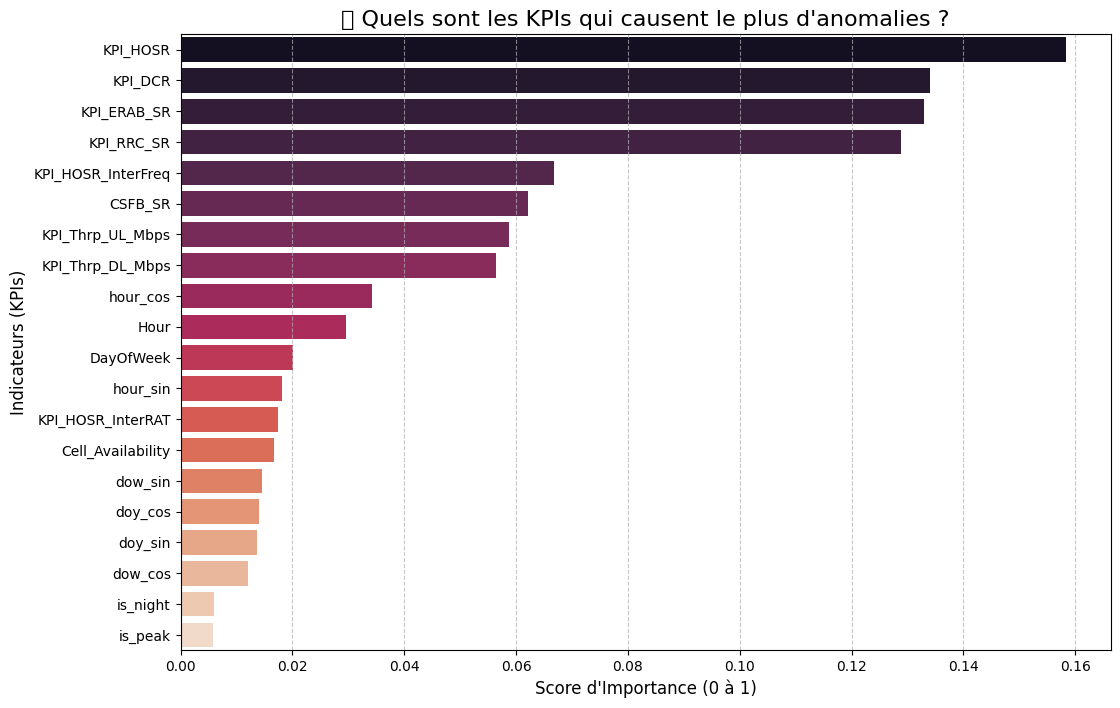


🔥 TOP 5 des indicateurs les plus impactants :
                  KPI  Importance
5            KPI_HOSR    0.158413
1             KPI_DCR    0.133943
2         KPI_ERAB_SR    0.132928
0          KPI_RRC_SR    0.128848
6  KPI_HOSR_InterFreq    0.066741


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("⏳ Préparation des données...")
# 1. On transforme notre texte en chiffres pour que l'IA comprenne (Anomalie = 1, Normal = 0)
y = df_ml['Statut_Reseau'].apply(lambda x: 1 if 'Anomalie' in x else 0)
X = X_scaled  # On réutilise nos données mathématiques mises à l'échelle

print("🌳 Entraînement du Random Forest en cours... (Cela peut prendre 1 à 2 minutes)")
# 2. Création et entraînement du modèle (100 arbres de décision)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 3. Extraction de l'importance de chaque KPI
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'KPI': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 4. Création du graphique (Le Podium)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='KPI', data=feature_df, palette='rocket')
plt.title('🏆 Quels sont les KPIs qui causent le plus d\'anomalies ?', fontsize=16)
plt.xlabel('Score d\'Importance (0 à 1)', fontsize=12)
plt.ylabel('Indicateurs (KPIs)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Affichage du top 5 en texte
print("\n🔥 TOP 5 des indicateurs les plus impactants :")
print(feature_df.head(5))

**Sauvegarde Random Forest**

In [ ]:
import joblib, os

# ══════════════════════════════════════════════════════════════
# 💾 SAUVEGARDE — Random Forest Classifier
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Sauvegarder le modèle
joblib.dump(rf_model, f'{SAVE_DIR}/random_forest.pkl')

# Sauvegarder l'importance des features
feature_df.to_csv(f'{SAVE_DIR}/rf_feature_importance.csv', index=False)

print(f"✅ Random Forest sauvegardé     : {SAVE_DIR}/random_forest.pkl")
print(f"✅ Importance des features      : {SAVE_DIR}/rf_feature_importance.csv")
print(f"   Nombre d'arbres              : {rf_model.n_estimators}")
print(f"   Features utilisées           : {rf_model.n_features_in_}")

✅ Random Forest sauvegardé     : /content/drive/MyDrive/P2M_Models/random_forest.pkl
✅ Importance des features      : /content/drive/MyDrive/P2M_Models/rf_feature_importance.csv
   Nombre d'arbres              : 100
   Features utilisées           : 20


**Chargement Random Forest (après reconnexion)**

In [ ]:
import joblib, pandas as pd

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Random Forest (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'

rf_model   = joblib.load(f'{SAVE_DIR}/random_forest.pkl')
feature_df = pd.read_csv(f'{SAVE_DIR}/rf_feature_importance.csv')

print("✅ Random Forest rechargé")
print(f"   Nombre d'arbres    : {rf_model.n_estimators}")
print(f"   Features utilisées : {rf_model.n_features_in_}")
print("\n🔥 TOP 5 des KPIs les plus impactants :")
print(feature_df.head(5))

✅ Random Forest rechargé
   Nombre d'arbres    : 100
   Features utilisées : 20

🔥 TOP 5 des KPIs les plus impactants :
                  KPI  Importance
0            KPI_HOSR    0.158413
1             KPI_DCR    0.133943
2         KPI_ERAB_SR    0.132928
3          KPI_RRC_SR    0.128848
4  KPI_HOSR_InterFreq    0.066741


**Autoencoder**

⌛ Prparation des donnes pour le Deep Learning...
ǱĂ Lancement de l'entra	nement...
Epoch 1/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.1231 - val_loss: 0.0048
Epoch 2/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0029 - val_loss: 0.0012
Epoch 3/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 4/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0020 - val_loss: 8.7019e-04
Epoch 5/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0018 - val_loss: 5.8501e-04
Epoch 6/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 9.5237e-04 - val_loss: 5.9605e-04
Epoch 7/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0013 - val_loss: 7.6732e-04
Epoch 8/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0013 - val_loss: 5.0756e-04
Epoch 9/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 9.8078e-04 - val_loss: 0.0027
Epoch 10/10
3411/3411 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0013 - val_loss: 4.2721e-04

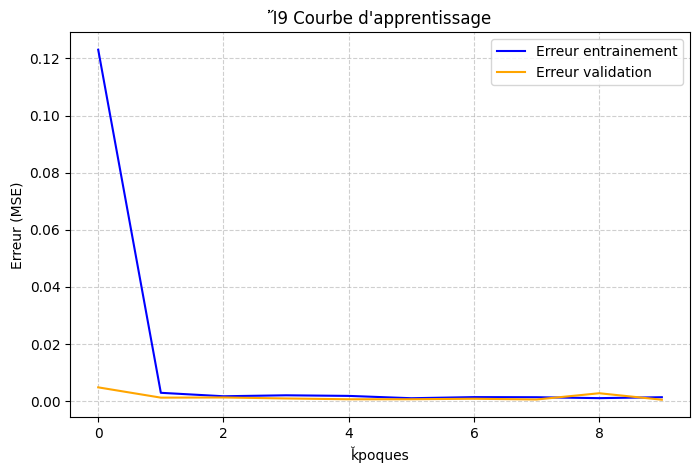

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
# Utilisation de layers directement pour plus de robustesse
from tensorflow.keras.layers import Input, Dense
import numpy as np
import matplotlib.pyplot as plt

print("⌛ Prparation des donnes pour le Deep Learning...")

# Correction des noms de colonnes : ajout du prfixe 'KPI_'
mes_10_kpis = [
    'KPI_RRC_SR', 'KPI_DCR', 'KPI_ERAB_SR',
    'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps',
    'KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
    'Cell_Availability', 'CSFB_SR'
]

X_normal = X_scaled[df_ml['Statut_Reseau'] == 'Normal ✅']

# On vrifie si les colonnes existent avant de filtrer
X_normal_pur = X_normal[mes_10_kpis]

# 3. Architecture de l'Autoencoder
input_dim = X_normal_pur.shape[1]
input_layer = Input(shape=(input_dim,))

# L'Encodeur
encoder = Dense(16, activation='relu')(input_layer)
encoder = Dense(8, activation='relu')(encoder)

# Le Dcodeur
decoder = Dense(16, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

print("ǱĂ Lancement de l'entra	nement...")
history = autoencoder.fit(X_normal_pur, X_normal_pur,
                          epochs=10,
                          batch_size=512,
                          validation_split=0.1,
                          verbose=1)

# 5. Affichage des courbes
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Erreur entrainement', color='blue')
plt.plot(history.history['val_loss'], label='Erreur validation', color='orange')
plt.title('Ἴ9 Courbe d\'apprentissage')
plt.xlabel('ǩpoques')
plt.ylabel('Erreur (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 💾 Sauvegarde Autoencoder

In [ ]:
import os, joblib
import numpy as np

# ══════════════════════════════════════════════════════════════
# 💾 SAUVEGARDE — Autoencoder (Keras)
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Sauvegarder le modèle Keras complet (architecture + poids)
autoencoder.save(f'{SAVE_DIR}/autoencoder.keras')

# Sauvegarder l'historique d'entraînement
import pandas as pd
pd.DataFrame(history.history).to_csv(f'{SAVE_DIR}/autoencoder_history.csv', index=False)

print(f"✅ Autoencoder sauvegardé : {SAVE_DIR}/autoencoder.keras")
print(f"✅ Historique d'entraînement sauvegardé")

✅ Autoencoder sauvegardé : /content/drive/MyDrive/P2M_Models/autoencoder.keras
✅ Historique d'entraînement sauvegardé


### 🔄 Chargement Autoencoder (après reconnexion)

In [ ]:
import tensorflow as tf
import pandas as pd

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Autoencoder (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'

autoencoder = tf.keras.models.load_model(f'{SAVE_DIR}/autoencoder.keras')

# Recharger l'historique pour les graphiques
history_df  = pd.read_csv(f'{SAVE_DIR}/autoencoder_history.csv')

print("✅ Autoencoder rechargé")
autoencoder.summary()

✅ Autoencoder rechargé


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.35 KB)

 Trainable params: 626 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,254 (4.90 KB)

Autoencoder :La Chasse aux Signaux Faibles

In [ ]:
import numpy as np

print("🔍 Lancement du scanner de signaux faibles (Prédiction)...")

# 1. On prend TOUT ton dataset (mis à l'échelle), mais uniquement les 10 KPIs purs
# Assure-toi que X_scaled est bien ton tableau complet d'origine contenant toutes les lignes (Normales + Anomalies)
# Si X_scaled est un numpy array (ce qui est souvent le cas après StandardScaler), on le convertit en DataFrame pour filtrer facilement
X_tout_pur = pd.DataFrame(X_scaled, columns=df_ml.columns)[mes_10_kpis]

# 2. On demande à l'Autoencoder de tout reconstruire
reconstructions = autoencoder.predict(X_tout_pur)

# 3. On calcule la note d'erreur (MSE) pour CHAQUE ligne de ton dataset
# C'est la différence mathématique entre la réalité et la reconstruction de l'IA
erreurs_mse = np.mean(np.power(X_tout_pur - reconstructions, 2), axis=1)

# 4. On fixe notre seuil de tolérance.
# Par exemple : on considère que les 2% des lignes avec les plus grosses erreurs sont des pannes critiques.
seuil = np.percentile(erreurs_mse, 98)

# 5. On sauvegarde les résultats dans ton DataFrame principal
df_ml['Erreur_Autoencoder'] = erreurs_mse
df_ml['Anomalie_DeepLearning'] = df_ml['Erreur_Autoencoder'] > seuil

# 6. Bilan de l'opération
nb_anomalies_dl = df_ml['Anomalie_DeepLearning'].sum()
print(f"✅ Terminé ! Le Deep Learning a scanné le réseau.")
print(f"Le seuil critique a été calculé à : {seuil:.4f}")
print(f"🚨 Nombre de signaux faibles (anomalies) détectés par l'Autoencoder : {nb_anomalies_dl}")

🔍 Lancement du scanner de signaux faibles (Prédiction)...
61235/61235 ━━━━━━━━━━━━━━━━━━━━ 86s 1ms/step
✅ Terminé ! Le Deep Learning a scanné le réseau.
Le seuil critique a été calculé à : 0.0019
🚨 Nombre de signaux faibles (anomalies) détectés par l'Autoencoder : 39191


In [ ]:
# 1. On filtre le tableau pour ne garder que les 39 191 lignes d'anomalies
anomalies_autoencoder = df_ml[df_ml['Anomalie_DeepLearning'] == True]

# 2. On les trie pour voir les PIRES anomalies tout en haut (ordre décroissant)
anomalies_autoencoder = anomalies_autoencoder.sort_values(by='Erreur_Autoencoder', ascending=False)

# 3. On sélectionne les colonnes les plus intéressantes à afficher
# (Si tu n'as pas de colonne 'Time' ou 'Cell_Name', modifie cette liste avec tes vrais noms de colonnes)
colonnes_visuelles = ['Cell_Name', 'Time', 'Erreur_Autoencoder', 'KPI_RRC_SR', 'KPI_DCR', 'KPI_ERAB_SR',
    'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps',
    'KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
    'Cell_Availability', 'CSFB_SR']
colonnes_existantes = [col for col in colonnes_visuelles if col in anomalies_autoencoder.columns]

# 4. On affiche le TOP 10 des pires signaux faibles !
print("🚨 TOP 10 des pires signaux faibles détectés par le Deep Learning :")
display(anomalies_autoencoder[colonnes_existantes].head(10))

# Optionnel : Afficher les statistiques de ces anomalies pour comprendre ce qui cloche
print("\n📊 Moyenne des KPIs lors de ces anomalies :")
display(anomalies_autoencoder[mes_10_kpis].mean())

🚨 TOP 10 des pires signaux faibles détectés par le Deep Learning :


,Cell_Name,Time,Erreur_Autoencoder,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,KPI_HOSR_InterFreq,KPI_HOSR_InterRAT,Cell_Availability,CSFB_SR
1330983,ROCADE_NORD02_T6,2025-06-04 08:00:00,79.563219,100.000000,50.000000,66.666667,0.609000,0.579200,83.333333,100.000000,100.0,100.000000,100.000000
1646393,THIOSSANE03_e2,2025-06-02 07:00:00,58.582018,100.000000,6.250000,100.000000,6.127215,2.106376,100.000000,100.000000,100.0,100.000000,70.370370
1129874,NDOUCOUMANE_e6,2025-06-01 20:00:00,35.725188,100.000000,4.726368,98.915989,24.378972,1.452016,96.666667,100.000000,100.0,12.916667,87.500000
1170677,NIANGHANA_e1,2025-06-02 01:00:00,19.752030,100.000000,25.000000,83.333333,3.490508,0.735481,94.782609,100.000000,100.0,100.000000,100.000000
579937,HLM06_e2,2025-06-04 16:00:00,18.221938,99.585921,10.081744,100.000000,12.065327,1.376095,99.141631,99.487179,100.0,100.000000,92.307692
1864642,VDN05_e9,2025-06-02 18:00:00,12.684941,42.389698,2.244898,99.345182,12.728272,1.861789,97.172414,100.000000,100.0,100.000000,94.017094
1864348,VDN05_e4,2025-06-02 18:00:00,12.577461,44.632018,2.560195,99.267557,15.562995,1.629573,96.779567,98.901099,100.0,100.000000,94.000000
1310876,PU14_DID_e3,2025-06-03 02:00:00,10.669493,97.435897,2.631579,100.000000,9.219488,0.976206,100.000000,100.000000,100.0,100.000000,71.428571
1646481,THIOSSANE03_e3,2025-06-01 19:00:00,10.407371,100.000000,2.631579,100.000000,9.293354,2.368848,98.529412,100.000000,100.0,100.000000,50.000000
1864250,VDN05_e3,2025-06-02 18:00:00,10.127319,45.544992,1.959824,99.295775,9.323562,4.110532,96.551724,99.004975,100.0,100.000000,94.594595



📊 Moyenne des KPIs lors de ces anomalies :


,0
KPI_RRC_SR,98.067200
KPI_DCR,0.370445
KPI_ERAB_SR,99.339101
KPI_Thrp_DL_Mbps,17.902130
KPI_Thrp_UL_Mbps,2.900748
KPI_HOSR,97.164456
KPI_HOSR_InterFreq,98.289010
KPI_HOSR_InterRAT,98.468329
Cell_Availability,92.935286
CSFB_SR,98.742804


**Sauvegarde des résultats Autoencoder (signaux faibles)**

In [ ]:
import os
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════
# 💾 SAUVEGARDE — Résultats Autoencoder (Signaux Faibles)
# ══════════════════════════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Sauvegarder le seuil critique calculé
np.save(f'{SAVE_DIR}/ae_seuil.npy', np.array([seuil]))

# 2. Sauvegarder toutes les erreurs MSE (une valeur par ligne du dataset)
np.save(f'{SAVE_DIR}/ae_erreurs_mse.npy', erreurs_mse)

# 3. Sauvegarder le DataFrame complet avec les colonnes Autoencoder
cols_ae = ['Cell_Name', 'Time', 'Erreur_Autoencoder', 'Anomalie_DeepLearning',
           'KPI_RRC_SR', 'KPI_DCR', 'KPI_ERAB_SR',
           'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps',
           'KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
           'Cell_Availability', 'CSFB_SR']
cols_ok = [c for c in cols_ae if c in df_ml.columns]
df_ml[cols_ok].to_csv(f'{SAVE_DIR}/ae_resultats_complets.csv', index=False)

# 4. Sauvegarder uniquement les anomalies (tableau trié)
anomalies_autoencoder.to_csv(f'{SAVE_DIR}/ae_anomalies_top.csv', index=False)

# 5. Sauvegarder les statistiques moyennes des anomalies
stats_anomalies = anomalies_autoencoder[mes_10_kpis].mean()
stats_anomalies.to_csv(f'{SAVE_DIR}/ae_stats_anomalies.csv', header=['Moyenne'])

print(f"✅ Seuil critique sauvegardé       : ae_seuil.npy        → {seuil:.4f}")
print(f"✅ Erreurs MSE sauvegardées         : ae_erreurs_mse.npy  → {len(erreurs_mse):,} valeurs")
print(f"✅ Résultats complets sauvegardés   : ae_resultats_complets.csv")
print(f"✅ Anomalies (triées) sauvegardées  : ae_anomalies_top.csv → {len(anomalies_autoencoder):,} lignes")
print(f"✅ Stats moyennes sauvegardées      : ae_stats_anomalies.csv")

✅ Seuil critique sauvegardé       : ae_seuil.npy        → 0.0019
✅ Erreurs MSE sauvegardées         : ae_erreurs_mse.npy  → 1,959,516 valeurs
✅ Résultats complets sauvegardés   : ae_resultats_complets.csv
✅ Anomalies (triées) sauvegardées  : ae_anomalies_top.csv → 39,191 lignes
✅ Stats moyennes sauvegardées      : ae_stats_anomalies.csv


**Chargement des résultats Autoencoder (après reconnexion)**

In [ ]:
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — Résultats Autoencoder (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans recalculer

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'

# 1. Recharger le seuil et les erreurs MSE
seuil        = float(np.load(f'{SAVE_DIR}/ae_seuil.npy')[0])
erreurs_mse  = np.load(f'{SAVE_DIR}/ae_erreurs_mse.npy')

# 2. Recharger les résultats complets
df_ae_complet = pd.read_csv(f'{SAVE_DIR}/ae_resultats_complets.csv')

# 3. Recharger les anomalies triées
anomalies_autoencoder = pd.read_csv(f'{SAVE_DIR}/ae_anomalies_top.csv')

# 4. Recharger les stats moyennes
stats_anomalies = pd.read_csv(f'{SAVE_DIR}/ae_stats_anomalies.csv', index_col=0)

# 5. Ré-afficher les résultats comme si on venait de les calculer
nb_anomalies_dl = len(anomalies_autoencoder)
print(f"✅ Résultats Autoencoder rechargés !")
print(f"   Seuil critique            : {seuil:.4f}")
print(f"   Erreurs MSE               : {len(erreurs_mse):,} valeurs")
print(f"   Anomalies détectées       : {nb_anomalies_dl:,}")

colonnes_visuelles = ['Cell_Name', 'Time', 'Erreur_Autoencoder', 'KPI_RRC_SR', 'KPI_DCR', 'KPI_ERAB_SR',
    'KPI_Thrp_DL_Mbps', 'KPI_Thrp_UL_Mbps',
    'KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
    'Cell_Availability', 'CSFB_SR']
colonnes_existantes = [col for col in colonnes_visuelles if col in anomalies_autoencoder.columns]

print("\n🚨 TOP 10 des pires signaux faibles :")
display(anomalies_autoencoder[colonnes_existantes].head(10))

print("\n📊 Moyenne des KPIs lors de ces anomalies :")
display(stats_anomalies)

✅ Résultats Autoencoder rechargés !
   Seuil critique            : 0.0019
   Erreurs MSE               : 1,959,516 valeurs
   Anomalies détectées       : 39,191

🚨 TOP 10 des pires signaux faibles :


,Cell_Name,Time,Erreur_Autoencoder,KPI_RRC_SR,KPI_DCR,KPI_ERAB_SR,KPI_Thrp_DL_Mbps,KPI_Thrp_UL_Mbps,KPI_HOSR,KPI_HOSR_InterFreq,KPI_HOSR_InterRAT,Cell_Availability,CSFB_SR
0,ROCADE_NORD02_T6,2025-06-04 08:00:00,79.563219,100.000000,50.000000,66.666667,0.609000,0.579200,83.333333,100.000000,100.0,100.000000,100.000000
1,THIOSSANE03_e2,2025-06-02 07:00:00,58.582018,100.000000,6.250000,100.000000,6.127215,2.106376,100.000000,100.000000,100.0,100.000000,70.370370
2,NDOUCOUMANE_e6,2025-06-01 20:00:00,35.725188,100.000000,4.726368,98.915989,24.378972,1.452016,96.666667,100.000000,100.0,12.916667,87.500000
3,NIANGHANA_e1,2025-06-02 01:00:00,19.752030,100.000000,25.000000,83.333333,3.490508,0.735481,94.782609,100.000000,100.0,100.000000,100.000000
4,HLM06_e2,2025-06-04 16:00:00,18.221938,99.585921,10.081744,100.000000,12.065327,1.376095,99.141631,99.487179,100.0,100.000000,92.307692
5,VDN05_e9,2025-06-02 18:00:00,12.684941,42.389698,2.244898,99.345182,12.728272,1.861789,97.172414,100.000000,100.0,100.000000,94.017094
6,VDN05_e4,2025-06-02 18:00:00,12.577461,44.632018,2.560195,99.267557,15.562995,1.629573,96.779567,98.901099,100.0,100.000000,94.000000
7,PU14_DID_e3,2025-06-03 02:00:00,10.669493,97.435897,2.631579,100.000000,9.219488,0.976206,100.000000,100.000000,100.0,100.000000,71.428571
8,THIOSSANE03_e3,2025-06-01 19:00:00,10.407371,100.000000,2.631579,100.000000,9.293354,2.368848,98.529412,100.000000,100.0,100.000000,50.000000
9,VDN05_e3,2025-06-02 18:00:00,10.127319,45.544992,1.959824,99.295775,9.323562,4.110532,96.551724,99.004975,100.0,100.000000,94.594595



📊 Moyenne des KPIs lors de ces anomalies :


,Moyenne
KPI_RRC_SR,98.067200
KPI_DCR,0.370445
KPI_ERAB_SR,99.339101
KPI_Thrp_DL_Mbps,17.902130
KPI_Thrp_UL_Mbps,2.900748
KPI_HOSR,97.164456
KPI_HOSR_InterFreq,98.289010
KPI_HOSR_InterRAT,98.468329
Cell_Availability,92.935286
CSFB_SR,98.742804


---
## 🧠 LSTM — 5 Prédictions KPI indépendantes basées sur les dépendances causales

Chaque modèle LSTM prédit **un KPI cible** avec les features **causalement justifiées** :

| # | KPI cible | Features clés | Valeur ajoutée LSTM |
|---|---|---|---|
| 1 | **KPI_DCR** | KPI_HOSR, InterFreq, InterRAT, RRC_SR | Lag 15–45 min HOSR→DCR |
| 2 | **KPI_HOSR** | InterFreq, InterRAT, Thrp_DL, RRC_SR | Cycles interférences |
| 3 | **KPI_Thrp_DL_Mbps** | ERAB_SR, RRC_SR, UL, HOSR | Cycles charge DL |
| 4 | **L.Thrp.bits.UL** | ERAB_SR, RRC_SR, Thrp_DL, HOSR | Cycles charge UL |
| 5 | **KPI_ERAB_SR** | RRC_SR, Delta_ERAB, Thrp_DL | Dégradation bearer vs radio |

**Architecture** : Cell Embedding 32d · Fenêtre 50h · 2×LSTM(64) · EarlyStopping patience=10
**Transformations** : log1p sur KPI_DCR et L.Thrp.bits.UL · Delta_ERAB feature différentielle


In [ ]:
# ══════════════════════════════════════════════════════════════
# IMPORTS & CONFIGURATION GLOBALE v4 — 5 LSTM optimisés
# ══════════════════════════════════════════════════════════════
import os, time, warnings, gc
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")

# ── Hyperparamètres communs ───────────────────────────────────
EMBED_DIM     = 32
HIDDEN_SIZE   = 128    # ↑ 64→128 : plus de capacité pour capturer les patterns rares
N_LSTM_LAYERS = 2
DROPOUT       = 0.2    # ↑ 0.1→0.2 : régularisation renforcée contre l'overfitting
LR            = 1e-3   # ↑ 5e-5→1e-3 : LR initial plus élevé, scheduler descend ensuite
BATCH_SIZE    = 128    # ↑ 64→128 : gradients plus stables sur distributions asymétriques
EPOCHS        = 80     # ↑ 50→80  : laisser plus de temps avec EarlyStopping
PATIENCE      = 15     # ↑ 10→15  : moins agressif, évite les faux stop
TRAIN_RATIO   = 0.80
TEMPORAL_FEATS = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

# ── Définition des 5 tâches LSTM — optimisées v4 ─────────────
# Changements clés vs v3 :
#   1. SEQ_LEN différencié : DCR/HOSR=24h, Thrp=168h (cycle hebdo), ERAB=24h
#   2. loss_fn différencié : Huber pour DCR/HOSR (zero-inflated), MSE pour Thrp/ERAB
#   3. hidden_size=128 pour tous (vs 64)
#   4. features enrichies avec lags explicites pour DCR

LSTM_TASKS = {

    # ── LSTM 1 : KPI_DCR ──────────────────────────────────────
    # Problème v3 : MSE diverge car DCR zero-inflated (70-80% zéros)
    # Fix v4 :
    #   - Huber loss (delta=0.1) : ignore les zéros, se concentre sur les pics
    #   - SEQ_LEN=24 : le lag HOSR→DCR est 1-3h, pas besoin de 50h
    #   - Feature : KPI_DCR_lag1, KPI_DCR_lag3 (valeurs passées explicites)
    'KPI_DCR': {
        'target'    : ['KPI_DCR'],
        'features'  : ['KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
                       'KPI_RRC_SR', 'Cell_Availability', 'CSFB_SR',
                       'KPI_DCR_lag1', 'KPI_DCR_lag3'],  # lags explicites
        'log_target': True,
        'seq_len'   : 24,      # ← 24h suffit (lag réel = 1-3h)
        'loss'      : 'huber', # ← Huber robuste aux zéros
        'huber_delta': 0.5,
        'color'     : '#d62728',
        'desc'      : 'Drop Call Rate — Huber loss, SEQ=24h, lags explicites',
    },

    # ── LSTM 2 : KPI_HOSR ─────────────────────────────────────
    # Problème v3 : distribution bimodale (99%≈100%, chutes rares)
    # Fix v4 :
    #   - Huber loss : pénalise moins les faux positifs sur la zone normale
    #   - SEQ_LEN=24 : les interférences sont des événements courts
    #   - Weighted loss : pondérer les chutes (HOSR < 90%) × 5
    'KPI_HOSR': {
        'target'    : ['KPI_HOSR'],
        'features'  : ['KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT',
                       'KPI_Thrp_DL_Mbps', 'KPI_RRC_SR',
                       'Cell_Availability', 'CSFB_SR',
                       'KPI_HOSR_lag1'],  # lag explicite
        'log_target': False,
        'seq_len'   : 24,
        'loss'      : 'huber',
        'huber_delta': 0.1,    # delta petit = très robuste aux outliers
        'color'     : '#ff7f0e',
        'desc'      : 'Handover SR — Huber loss, SEQ=24h, lag explicite',
    },

    # ── LSTM 3 : KPI_Thrp_DL_Mbps ────────────────────────────
    # v3 déjà acceptable — améliorations :
    #   - SEQ_LEN=168h : capturer le cycle hebdomadaire complet (7 jours)
    #   - MSE standard : distribution continue, pas de problème zero-inflated
    #   - Ajout is_weekend, is_peak comme features binaires
    'KPI_Thrp_DL_Mbps': {
        'target'    : ['KPI_Thrp_DL_Mbps'],
        'features'  : ['KPI_ERAB_SR', 'KPI_RRC_SR', 'KPI_Thrp_UL_Mbps',
                       'KPI_HOSR', 'Cell_Availability',
                       'is_peak', 'is_night'],  # contexte charge
        'log_target': False,
        'seq_len'   : 168,     # ← 7 jours = cycle hebdomadaire complet
        'loss'      : 'mse',
        'color'     : '#1f77b4',
        'desc'      : 'Débit DL — MSE, SEQ=168h (cycle hebdo), features charge',
    },

    # ── LSTM 4 : KPI_Thrp_UL_Mbps ────────────────────────────
    # Correction v3 : la cible était 'KPI_Thrp_UL_Mbps' mais le task name
    # était 'L.Thrp.bits.UL' → confusion. On normalise ici.
    # SEQ_LEN=168h pour le même cycle hebdomadaire
    'KPI_Thrp_UL_Mbps': {
        'target'    : ['KPI_Thrp_UL_Mbps'],
        'features'  : ['KPI_ERAB_SR', 'KPI_RRC_SR', 'KPI_Thrp_DL_Mbps',
                       'KPI_HOSR', 'Cell_Availability',
                       'is_peak', 'is_night'],
        'log_target': False,
        'seq_len'   : 168,
        'loss'      : 'mse',
        'color'     : '#9467bd',
        'desc'      : 'Débit UL — MSE, SEQ=168h (cycle hebdo), features charge',
    },

    # ── LSTM 5 : KPI_ERAB_SR ─────────────────────────────────
    # Problème v3 : distribution quasi-constante (97-100%) → MSE prédit la moyenne
    # Fix v4 :
    #   - Huber loss (delta=0.05) : se concentre sur les rares chutes
    #   - Contrainte physique : prédiction clippée à [0, KPI_RRC_SR]
    #   - Delta_ERAB enrichi : séparation radio vs cœur
    'KPI_ERAB_SR': {
        'target'    : ['KPI_ERAB_SR'],
        'features'  : ['KPI_RRC_SR', 'Delta_ERAB', 'KPI_Thrp_DL_Mbps',
                       'Cell_Availability', 'CSFB_SR',
                       'KPI_ERAB_SR_lag1'],  # autorégressif
        'log_target': False,
        'seq_len'   : 24,
        'loss'      : 'huber',
        'huber_delta': 0.05,   # très petit : focus absolu sur les chutes
        'color'     : '#2ca02c',
        'desc'      : 'ERAB SR — Huber loss, SEQ=24h, contrainte RRC, autorégressif',
    },
}

print(f"\n✅ {len(LSTM_TASKS)} tâches LSTM v4 définies :")
for name, cfg in LSTM_TASKS.items():
    print(f"   → {name:<22} SEQ={cfg['seq_len']:>3}h  loss={cfg['loss']:<5}  "
          f"log={str(cfg['log_target']):<5}  features={len(cfg['features'])}")


✅ Device : cuda
   GPU : Tesla T4

✅ 5 tâches LSTM v4 définies :
   → KPI_DCR                SEQ= 24h  loss=huber  log=True   features=8
   → KPI_HOSR               SEQ= 24h  loss=huber  log=False  features=7
   → KPI_Thrp_DL_Mbps       SEQ=168h  loss=mse    log=False  features=7
   → KPI_Thrp_UL_Mbps       SEQ=168h  loss=mse    log=False  features=7
   → KPI_ERAB_SR            SEQ= 24h  loss=huber  log=False  features=6


In [ ]:
# ══════════════════════════════════════════════════════════════
# FONCTIONS UTILITAIRES v4 — corrections des bugs v3
# ══════════════════════════════════════════════════════════════

# ── Dataset PyTorch (inchangé) ────────────────────────────────
class TelecomDataset(Dataset):
    def __init__(self, df, seq_len, feat_cols, target_cols):
        seqs, tgts, cids = [], [], []
        feat_plus_t = feat_cols + ['time_id_norm']
        for cid, grp in df.groupby('cell_id'):
            grp   = grp.sort_values('Time').reset_index(drop=True)
            X_arr = grp[feat_plus_t].values.astype(np.float32)
            y_arr = grp[target_cols].values.astype(np.float32)
            for i in range(seq_len, len(X_arr)):
                seqs.append(X_arr[i - seq_len : i])
                tgts.append(y_arr[i])
                cids.append(int(cid))
        self.X   = torch.tensor(np.array(seqs), dtype=torch.float32)
        self.y   = torch.tensor(np.array(tgts), dtype=torch.float32)
        self.cid = torch.tensor(np.array(cids), dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.cid[i], self.y[i]


# ── Architecture LSTM v4 : hidden=128, BatchNorm ──────────────
class LSTMCellEmbedding(nn.Module):
    """
    LSTM avec Cell Embedding v4.
    Améliorations vs v3 :
    - hidden_size=128 (vs 64) : plus de capacité
    - BatchNorm1d avant FC : stabilise l'entraînement
    - FC élargi : 128→64→32→n_targets (vs 128→32→n_targets)
    """
    def __init__(self, n_features, n_cells, embed_dim,
                 hidden_size, n_layers, dropout, n_targets):
        super().__init__()
        self.embedding = nn.Embedding(n_cells, embed_dim)
        self.lstm = nn.LSTM(
            input_size  = n_features + embed_dim,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            dropout     = dropout if n_layers > 1 else 0.0,
            batch_first = True
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(32, n_targets)
        )
    def forward(self, x_seq, cell_ids):
        emb = self.embedding(cell_ids).unsqueeze(1).expand(-1, x_seq.size(1), -1)
        _, (h_n, _) = self.lstm(torch.cat([x_seq, emb], dim=-1))
        return self.fc(self.norm(h_n[-1]))


# ── Feature engineering : lags et features binaires ──────────
def add_lag_features(df_ml):
    """
    Ajoute les features de lag et features binaires manquantes.
    FIX v4 : fait UNE seule fois sur df_ml avant tout split.
    """
    df = df_ml.copy()

    # Lags explicites (triés par cellule et temps)
    df = df.sort_values(['Cell_Name', 'Time']).reset_index(drop=True)

    lag_specs = {
        'KPI_DCR_lag1'   : ('KPI_DCR',  1),
        'KPI_DCR_lag3'   : ('KPI_DCR',  3),
        'KPI_HOSR_lag1'  : ('KPI_HOSR', 1),
        'KPI_ERAB_SR_lag1': ('KPI_ERAB_SR', 1),
    }
    for feat_name, (col, lag) in lag_specs.items():
        if col in df.columns:
            df[feat_name] = df.groupby('Cell_Name')[col].shift(lag)
            df[feat_name] = df.groupby('Cell_Name')[feat_name].transform(
                lambda x: x.fillna(method='bfill').fillna(method='ffill'))
            print(f"   ✅ {feat_name} créé (lag={lag}h sur {col})")

    # Features binaires de contexte (si absentes)
    if 'is_peak' not in df.columns:
        hour = pd.to_datetime(df['Time']).dt.hour
        df['is_peak']  = ((hour >= 7) & (hour <= 21)).astype('float32')
        df['is_night'] = ((hour >= 0) & (hour <= 6)).astype('float32')
        print("   ✅ is_peak, is_night créés")

    # Delta_ERAB si absent
    if 'Delta_ERAB' not in df.columns:
        if 'KPI_ERAB_SR' in df.columns and 'KPI_RRC_SR' in df.columns:
            df['Delta_ERAB'] = df['KPI_ERAB_SR'] - df['KPI_RRC_SR']
            print("   ✅ Delta_ERAB créé")

    return df


# ── Split commun (FIX v4 : calculé UNE seule fois) ────────────
def compute_common_split(df_ml, train_ratio=0.80, seed=42):
    """
    FIX critique v3 : le split était recalculé dans chaque tâche.
    Ici on le calcule une seule fois et on le réutilise pour les 5 LSTM.
    Garantit que tous les modèles voient exactement les mêmes cellules train/test.
    """
    all_cells = df_ml['Cell_Name'].unique()
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(all_cells)
    n_train = int(len(shuffled) * train_ratio)
    train_names = set(shuffled[:n_train])
    test_names  = set(shuffled[n_train:])
    print(f"✅ Split commun : {len(train_names)} cellules train | {len(test_names)} cellules test")
    return train_names, test_names


# ── Préparation données v4 (FIX du leakage log1p) ────────────
def prepare_data_for_task_v4(df_enriched, task_cfg, cell_encoder,
                              train_names, test_names):
    """
    FIX v4 vs v3 :
    1. log1p appliqué APRÈS le split (plus de contamination du scaler)
    2. Split cellules FIXE (passé en paramètre, calculé une seule fois)
    3. Gestion NaN robuste sur les features de lag
    """
    feat_cols  = [f for f in task_cfg['features'] + TEMPORAL_FEATS
                  if f in df_enriched.columns]
    targets_ok = [t for t in task_cfg['target'] if t in df_enriched.columns]

    missing = set(task_cfg['features']) - set(feat_cols)
    if missing: print(f"   ⚠️  Features absentes : {missing}")
    if not targets_ok:
        print(f"   ❌ Cible {task_cfg['target']} absente")
        return None, None, None, None, feat_cols, targets_ok

    # Encodage cell_id
    df = df_enriched.copy()
    df = df.sort_values(['Cell_Name', 'Time']).reset_index(drop=True)
    df['cell_id'] = cell_encoder.transform(df['Cell_Name'])

    # time_id normalisé
    df['time_id_norm'] = (
        df.groupby('cell_id').cumcount() /
        df.groupby('cell_id')['cell_id'].transform('count')
    ).astype('float32')

    # Split FIXE (passé en paramètre)
    df_train = df[df['Cell_Name'].isin(train_names)].copy()
    df_test  = df[df['Cell_Name'].isin(test_names)].copy()

    # FIX : log1p appliqué SÉPARÉMENT sur train et test APRÈS split
    if task_cfg['log_target']:
        for col in targets_ok:
            df_train[col] = np.log1p(df_train[col])
            df_test[col]  = np.log1p(df_test[col])

    # Scalers fittés UNIQUEMENT sur train
    sc_in  = MinMaxScaler(feature_range=(0, 1))
    sc_tgt = MinMaxScaler(feature_range=(0, 1))
    df_train[feat_cols]  = sc_in.fit_transform(df_train[feat_cols].fillna(0))
    df_train[targets_ok] = sc_tgt.fit_transform(df_train[targets_ok].fillna(0))
    df_test[feat_cols]   = sc_in.transform(df_test[feat_cols].fillna(0))
    df_test[targets_ok]  = sc_tgt.transform(df_test[targets_ok].fillna(0))

    return df_train, df_test, sc_in, sc_tgt, feat_cols, targets_ok


# ── Loss functions ────────────────────────────────────────────
def get_loss_fn(task_cfg):
    """
    Retourne la loss adaptée à la distribution de chaque KPI.
    - MSE  : distributions continues et symétriques (Thrp_DL, Thrp_UL)
    - Huber: distributions zero-inflated ou bimodales (DCR, HOSR, ERAB)
              Huber = MSE pour |erreur| < delta, MAE sinon
              → robuste aux zéros et outliers sans les ignorer complètement
    """
    if task_cfg.get('loss', 'mse') == 'huber':
        delta = task_cfg.get('huber_delta', 0.1)
        return nn.HuberLoss(delta=delta)
    return nn.MSELoss()


# ── Entraînement v4 : LR plus élevé + warm restart ───────────
def train_lstm_v4(model, dl_train, dl_val, task_cfg, epochs, patience, lr):
    """
    Améliorations vs v3 :
    - Loss adaptée (Huber ou MSE selon la tâche)
    - CosineAnnealingLR au lieu de ReduceLROnPlateau :
        évite le LR qui s'effondre trop vite (cause de la divergence en v3)
    - Gradient clipping conservé
    """
    criterion = get_loss_fn(task_cfg)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # CosineAnnealing : LR oscille entre lr et lr/100 sur T_max epochs
    # → évite le plateau précoce de ReduceLROnPlateau
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr/100)

    train_losses, val_losses = [], []
    best_val, patience_c, best_state = float('inf'), 0, None

    print(f"   Loss : {type(criterion).__name__}"
          + (f"(delta={task_cfg.get('huber_delta')})" if task_cfg.get('loss')=='huber' else ""))
    print(f"{'─'*65}")
    print(f"{'Epoch':>6} {'Train':>12} {'Val':>12} {'LR':>10}  Statut")
    print(f"{'─'*65}")

    for epoch in range(1, epochs+1):
        model.train()
        bl = []
        for X_b, cid_b, y_b in dl_train:
            X_b,cid_b,y_b = X_b.to(DEVICE),cid_b.to(DEVICE),y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_b, cid_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); bl.append(loss.item())
        train_loss = np.mean(bl)

        model.eval(); vl = []
        with torch.no_grad():
            for X_b, cid_b, y_b in dl_val:
                X_b,cid_b,y_b = X_b.to(DEVICE),cid_b.to(DEVICE),y_b.to(DEVICE)
                vl.append(criterion(model(X_b,cid_b),y_b).item())
        val_loss = np.mean(vl)

        train_losses.append(train_loss); val_losses.append(val_loss)
        scheduler.step()
        cur_lr = optimizer.param_groups[0]['lr']; status = ''

        if val_loss < best_val:
            best_val=val_loss; patience_c=0
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
            status='✅ best'
        else:
            patience_c += 1
            if patience_c >= patience:
                print(f"{'─'*65}\n⛔ EarlyStopping epoch {epoch}"); break
        if epoch%5==0 or status:
            print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>12.6f} {cur_lr:>10.2e}  {status}")

    if best_state: model.load_state_dict(best_state)
    print(f"\n✅ Best val_loss={best_val:.6f}")
    return train_losses, val_losses, best_val


# ── Évaluation (inchangée dans la logique, MSE calculée séparément) ──
def evaluate_lstm(model, dl_val, sc_tgt, targets_ok, log_target, task_name, color):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_b, cid_b, y_b in dl_val:
            pred = model(X_b.to(DEVICE), cid_b.to(DEVICE)).cpu().numpy()
            all_preds.append(pred); all_true.append(y_b.numpy())

    preds_real = sc_tgt.inverse_transform(np.concatenate(all_preds))
    trues_real = sc_tgt.inverse_transform(np.concatenate(all_true))

    if log_target:
        preds_real = np.expm1(np.clip(preds_real, -10, 20))
        trues_real = np.expm1(trues_real)
        print(f"   ✅ expm1 inversé sur {task_name}")

    metrics = {}
    print(f"\n{'─'*65}")
    print(f"{'KPI':<22} {'MAE':>10} {'RMSE':>10} {'NRMSE%':>8} {'R²':>8}")
    print(f"{'─'*65}")
    for j, kpi in enumerate(targets_ok):
        y_t, y_p = trues_real[:,j], preds_real[:,j]
        mae  = np.mean(np.abs(y_t-y_p))
        rmse = np.sqrt(mean_squared_error(y_t,y_p))
        nrm  = rmse/(np.mean(y_t)+1e-8)*100
        r2   = r2_score(y_t,y_p)
        metrics[kpi] = dict(mae=mae,rmse=rmse,nrmse=nrm,r2=r2)
        if kpi in ['KPI_RRC_SR','KPI_ERAB_SR']:
            flag='✅' if mae<0.005 else ('⚠️' if mae<0.02 else '❌'); note='(eval MAE)'
        else:
            flag='✅' if r2>0.85 else ('⚠️' if r2>0.6 else '❌'); note=''
        print(f"{kpi:<22} {mae:>10.4f} {rmse:>10.4f} {nrm:>7.2f}% {r2:>8.4f} {flag} {note}")
    print(f"{'─'*65}")

    N_SHOW = min(400, len(trues_real))
    fig, axes = plt.subplots(len(targets_ok), 1, figsize=(16, 4*len(targets_ok)), sharex=True)
    if len(targets_ok)==1: axes=[axes]
    fig.suptitle(f'LSTM v4 — {task_name} : Prédiction vs Réel', fontsize=13, fontweight='bold')
    for j, kpi in enumerate(targets_ok):
        ax=axes[j]; y_t,y_p=trues_real[:N_SHOW,j],preds_real[:N_SHOW,j]
        ax.plot(y_t,color=color,lw=1.5,alpha=0.9,label=f'{kpi} — Réel')
        ax.plot(y_p,color='black',lw=1.2,alpha=0.75,ls='--',label=f'{kpi} — Prédit')
        ax.fill_between(range(N_SHOW),y_t,y_p,alpha=0.12,color=color)
        m=metrics[kpi]
        ax.set_title(f"{kpi}  |  MAE={m['mae']:.4f}  RMSE={m['rmse']:.4f}"
                     f"  NRMSE={m['nrmse']:.2f}%  R²={m['r2']:.4f}",
                     fontsize=10,fontweight='bold')
        ax.set_ylabel(kpi); ax.legend(fontsize=9); ax.grid(True,alpha=0.3,ls='--')
    axes[-1].set_xlabel('Pas de temps')
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, len(targets_ok), figsize=(5*len(targets_ok),5))
    if len(targets_ok)==1: axes=[axes]
    fig.suptitle(f'Scatter — {task_name}', fontsize=12, fontweight='bold')
    for j, kpi in enumerate(targets_ok):
        ax=axes[j]; y_t,y_p=trues_real[:,j],preds_real[:,j]
        ax.scatter(y_t,y_p,alpha=0.15,s=4,color=color,rasterized=True)
        lo,hi=min(y_t.min(),y_p.min()),max(y_t.max(),y_p.max())
        ax.plot([lo,hi],[lo,hi],'k--',lw=1.5)
        ax.set_title(f'{kpi}\nR²={metrics[kpi]["r2"]:.4f}',fontweight='bold')
        ax.set_xlabel(f'{kpi} Réel'); ax.set_ylabel('Prédit'); ax.grid(True,alpha=0.3)
    plt.tight_layout(); plt.show()
    return preds_real, trues_real, metrics

print("✅ Fonctions v4 chargées")
print("   Corrections : Huber loss | CosineAnnealingLR | split fixe | log1p post-split")


✅ Fonctions v4 chargées
   Corrections : Huber loss | CosineAnnealingLR | split fixe | log1p post-split


In [ ]:
# ══════════════════════════════════════════════════════════════
# SETUP COMMUN v4 — Feature engineering + Split unique
# ══════════════════════════════════════════════════════════════

print("📦 Enrichissement du dataset avec lags et features binaires...")
df_enriched = add_lag_features(df_ml)
print(f"   Shape enrichie : {df_enriched.shape}")

# Encodeur cellules commun
cell_encoder_global = LabelEncoder()
df_enriched = df_enriched.sort_values(['Cell_Name','Time']).reset_index(drop=True)
cell_encoder_global.fit(df_enriched['Cell_Name'])
N_CELLS_GLOBAL = len(cell_encoder_global.classes_)
print(f"\n✅ Encodeur : {N_CELLS_GLOBAL} cellules")

# FIX : split calculé UNE SEULE FOIS pour les 5 LSTM
train_names_global, test_names_global = compute_common_split(df_enriched)

lstm_results = {}
print("\n✅ Setup commun prêt — df_enriched, split, encodeur disponibles pour les 5 LSTM")


📦 Enrichissement du dataset avec lags et features binaires...
   ✅ KPI_DCR_lag1 créé (lag=1h sur KPI_DCR)
   ✅ KPI_DCR_lag3 créé (lag=3h sur KPI_DCR)
   ✅ KPI_HOSR_lag1 créé (lag=1h sur KPI_HOSR)
   ✅ KPI_ERAB_SR_lag1 créé (lag=1h sur KPI_ERAB_SR)
   ✅ Delta_ERAB créé
   Shape enrichie : (1959516, 33)

✅ Encodeur : 20250 cellules
✅ Split commun : 16200 cellules train | 4050 cellules test

✅ Setup commun prêt — df_enriched, split, encodeur disponibles pour les 5 LSTM



  LSTM 1/5 : KPI_DCR
  Drop Call Rate — Huber loss, SEQ=24h, lags explicites
   Train:1,567,491 | Test:392,025
   Features (12) : ['KPI_HOSR', 'KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT', 'KPI_RRC_SR', 'Cell_Availability', 'CSFB_SR', 'KPI_DCR_lag1', 'KPI_DCR_lag3', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
   Séquences Train:1,179,079 | Val:294,899
   Paramètres : 880,321

🚀 Entraînement LSTM_DCR v4 — 80 epochs max
   Loss : HuberLoss(delta=0.5)
─────────────────────────────────────────────────────────────────
 Epoch        Train          Val         LR  Statut
─────────────────────────────────────────────────────────────────
     1     0.000130     0.000099   1.00e-03  ✅ best
     4     0.000125     0.000099   9.94e-04  ✅ best
     5     0.000125     0.000099   9.90e-04  ✅ best
    10     0.000125     0.000099   9.62e-04  
    15     0.000125     0.000100   9.17e-04  
─────────────────────────────────────────────────────────────────
⛔ EarlyStopping epoch 20

✅ Best val_loss=0.00009

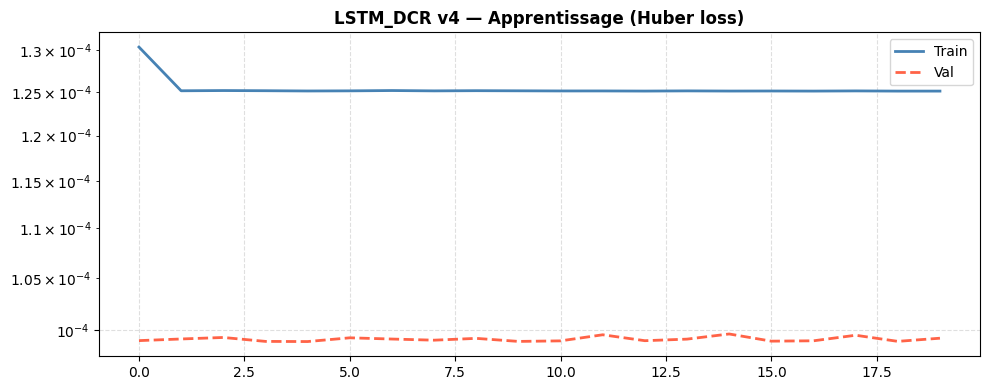

   ✅ expm1 inversé sur KPI_DCR

─────────────────────────────────────────────────────────────────
KPI                           MAE       RMSE   NRMSE%       R²
─────────────────────────────────────────────────────────────────
KPI_DCR                    0.0261     0.2094 1217.17%  -0.0003 ❌ 
─────────────────────────────────────────────────────────────────


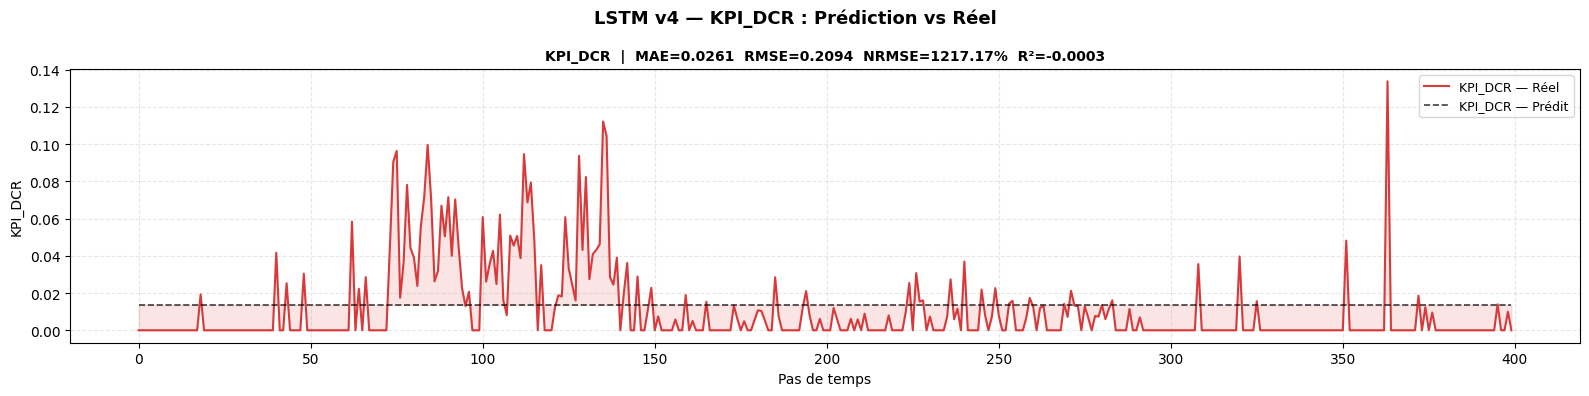

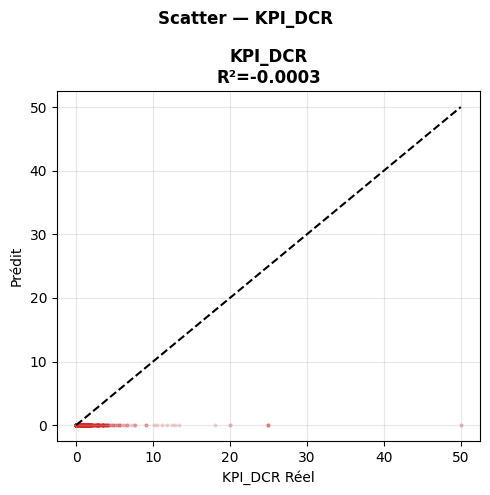

In [ ]:
# ══════════════════════════════════════════════════════════════
# LSTM 1/5 — KPI_DCR (Drop Call Rate) — v4
# ══════════════════════════════════════════════════════════════
TASK = 'KPI_DCR'; cfg = LSTM_TASKS[TASK]
print(f"\n{'='*65}\n  LSTM 1/5 : {TASK}\n  {cfg['desc']}\n{'='*65}")

df_tr1,df_te1,sc_in1,sc_tgt1,feats1,tgt1 = prepare_data_for_task_v4(
    df_enriched, cfg, cell_encoder_global, train_names_global, test_names_global)
print(f"   Train:{len(df_tr1):,} | Test:{len(df_te1):,}")
print(f"   Features ({len(feats1)}) : {feats1}")

ds_tr1 = TelecomDataset(df_tr1, cfg['seq_len'], feats1, tgt1)
ds_va1 = TelecomDataset(df_te1, cfg['seq_len'], feats1, tgt1)
dl_tr1 = DataLoader(ds_tr1, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=DEVICE.type=='cuda')
dl_va1 = DataLoader(ds_va1, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type=='cuda')
print(f"   Séquences Train:{len(ds_tr1):,} | Val:{len(ds_va1):,}")

model_dcr = LSTMCellEmbedding(len(feats1)+1, N_CELLS_GLOBAL, EMBED_DIM,
                               HIDDEN_SIZE, N_LSTM_LAYERS, DROPOUT, len(tgt1)).to(DEVICE)
print(f"   Paramètres : {sum(p.numel() for p in model_dcr.parameters()):,}")

print(f"\n🚀 Entraînement LSTM_DCR v4 — {EPOCHS} epochs max")
t0=time.time()
trl1,val1,bv1 = train_lstm_v4(model_dcr, dl_tr1, dl_va1, cfg, EPOCHS, PATIENCE, LR)
print(f"⏱  {(time.time()-t0)/60:.1f} min")

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(trl1,label='Train',color='steelblue',lw=2)
ax.plot(val1,label='Val',color='tomato',lw=2,ls='--')
ax.set_yscale('log'); ax.set_title('LSTM_DCR v4 — Apprentissage (Huber loss)',fontweight='bold')
ax.legend(); ax.grid(True,alpha=0.4,ls='--'); plt.tight_layout(); plt.show()

pr1,tr1,mt1 = evaluate_lstm(model_dcr,dl_va1,sc_tgt1,tgt1,cfg['log_target'],TASK,cfg['color'])
lstm_results[TASK] = dict(model=model_dcr,preds=pr1,trues=tr1,metrics=mt1,
    scaler_in=sc_in1,scaler_tgt=sc_tgt1,feats=feats1,targets=tgt1,
    train_losses=trl1,val_losses=val1,cfg=cfg)


### 🟠 LSTM 2/5 — KPI_HOSR


  LSTM 2/5 : KPI_HOSR
  Handover SR — Huber loss, SEQ=24h, lag explicite
   Train:1,567,491 | Test:392,025 | Features(11):['KPI_HOSR_InterFreq', 'KPI_HOSR_InterRAT', 'KPI_Thrp_DL_Mbps', 'KPI_RRC_SR', 'Cell_Availability', 'CSFB_SR', 'KPI_HOSR_lag1', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
   Séquences Train:1,179,079 | Val:294,899
   Paramètres : 879,809

🚀 Entraînement LSTM_HOSR v4 — 80 epochs max
   Loss : HuberLoss(delta=0.1)
─────────────────────────────────────────────────────────────────
 Epoch        Train          Val         LR  Statut
─────────────────────────────────────────────────────────────────
     1     0.001373     0.000661   1.00e-03  ✅ best
     2     0.000663     0.000661   9.98e-04  ✅ best
     5     0.000663     0.000661   9.90e-04  
    10     0.000663     0.000661   9.62e-04  
    15     0.000663     0.000661   9.17e-04  
─────────────────────────────────────────────────────────────────
⛔ EarlyStopping epoch 17

✅ Best val_loss=0.000661
⏱  15.9 min


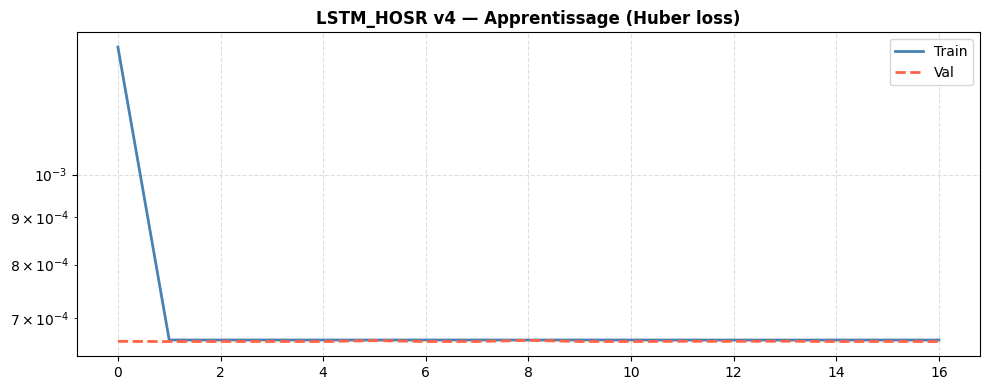


─────────────────────────────────────────────────────────────────
KPI                           MAE       RMSE   NRMSE%       R²
─────────────────────────────────────────────────────────────────
KPI_HOSR                   1.3025     6.5248    6.59%  -0.0063 ❌ 
─────────────────────────────────────────────────────────────────


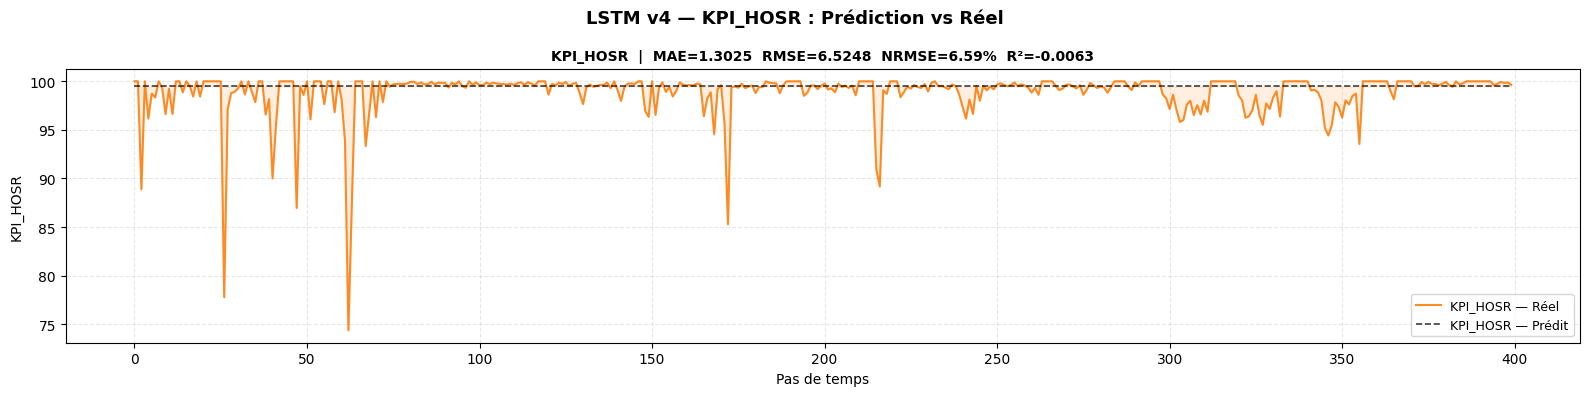

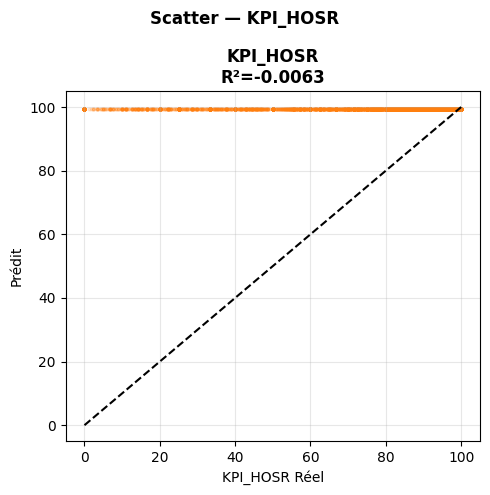

In [ ]:
# ══════════════════════════════════════════════════════════════
# LSTM 2/5 — KPI_HOSR (Handover Success Rate) — v4
# ══════════════════════════════════════════════════════════════
TASK = 'KPI_HOSR'; cfg = LSTM_TASKS[TASK]
print(f"\n{'='*65}\n  LSTM 2/5 : {TASK}\n  {cfg['desc']}\n{'='*65}")

df_tr2,df_te2,sc_in2,sc_tgt2,feats2,tgt2 = prepare_data_for_task_v4(
    df_enriched, cfg, cell_encoder_global, train_names_global, test_names_global)
print(f"   Train:{len(df_tr2):,} | Test:{len(df_te2):,} | Features({len(feats2)}):{feats2}")

ds_tr2 = TelecomDataset(df_tr2, cfg['seq_len'], feats2, tgt2)
ds_va2 = TelecomDataset(df_te2, cfg['seq_len'], feats2, tgt2)
dl_tr2 = DataLoader(ds_tr2, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=DEVICE.type=='cuda')
dl_va2 = DataLoader(ds_va2, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type=='cuda')
print(f"   Séquences Train:{len(ds_tr2):,} | Val:{len(ds_va2):,}")

model_hosr = LSTMCellEmbedding(len(feats2)+1, N_CELLS_GLOBAL, EMBED_DIM,
                                HIDDEN_SIZE, N_LSTM_LAYERS, DROPOUT, len(tgt2)).to(DEVICE)
print(f"   Paramètres : {sum(p.numel() for p in model_hosr.parameters()):,}")

print(f"\n🚀 Entraînement LSTM_HOSR v4 — {EPOCHS} epochs max")
t0=time.time()
trl2,val2,bv2 = train_lstm_v4(model_hosr, dl_tr2, dl_va2, cfg, EPOCHS, PATIENCE, LR)
print(f"⏱  {(time.time()-t0)/60:.1f} min")

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(trl2,label='Train',color='steelblue',lw=2)
ax.plot(val2,label='Val',color='tomato',lw=2,ls='--')
ax.set_yscale('log'); ax.set_title('LSTM_HOSR v4 — Apprentissage (Huber loss)',fontweight='bold')
ax.legend(); ax.grid(True,alpha=0.4,ls='--'); plt.tight_layout(); plt.show()

pr2,tr2,mt2 = evaluate_lstm(model_hosr,dl_va2,sc_tgt2,tgt2,cfg['log_target'],TASK,cfg['color'])
lstm_results[TASK] = dict(model=model_hosr,preds=pr2,trues=tr2,metrics=mt2,
    scaler_in=sc_in2,scaler_tgt=sc_tgt2,feats=feats2,targets=tgt2,
    train_losses=trl2,val_losses=val2,cfg=cfg)


### 🔵 LSTM 3/5 — KPI_Thrp_DL_Mbps


  LSTM 3/5 : KPI_Thrp_DL_Mbps
  Débit Descendant — dépend ERAB_SR + cycles temporels
   Train:1,567,491 | Test:392,025 | Features(9):['KPI_ERAB_SR', 'KPI_RRC_SR', 'KPI_Thrp_UL_Mbps', 'KPI_HOSR', 'Cell_Availability', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
   Séquences Train:759,583 | Val:189,999
   Paramètres : 711,169

🚀 Entraînement LSTM_Thrp_DL — 50 epochs max
─────────────────────────────────────────────────────────────────
 Epoch    Train MSE      Val MSE         LR  Statut
─────────────────────────────────────────────────────────────────
     1     0.004399     0.002908   5.00e-05  ✅ best
     2     0.002260     0.002554   5.00e-05  ✅ best
     4     0.001688     0.002687   5.00e-05  
     6     0.001381     0.003046   5.00e-05  
     8     0.001223     0.003296   2.50e-05  
    10     0.001149     0.003285   2.50e-05  
─────────────────────────────────────────────────────────────────
⛔ EarlyStopping epoch 12

✅ Meilleurs poids rechargés (val_loss=0.002554)
⏱  11.4 min


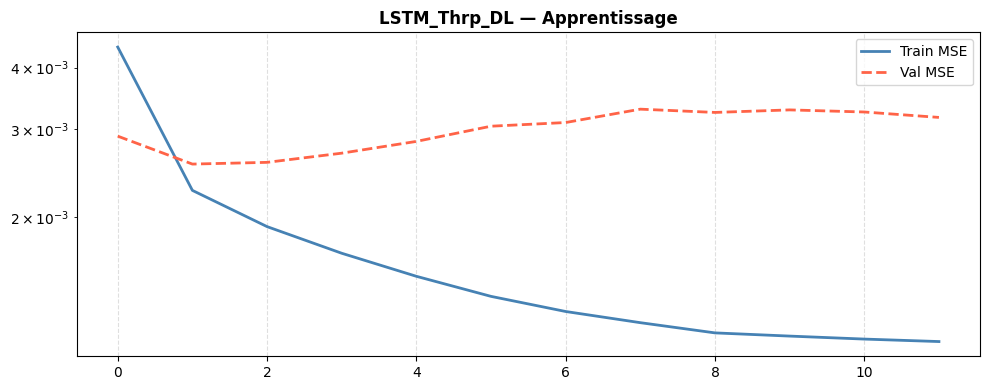


──────────────────────────────────────────────────────────────
KPI                           MAE       RMSE   NRMSE%       R²
──────────────────────────────────────────────────────────────
KPI_Thrp_DL_Mbps           5.6492     7.5290   40.68%   0.4357 ❌ 
──────────────────────────────────────────────────────────────


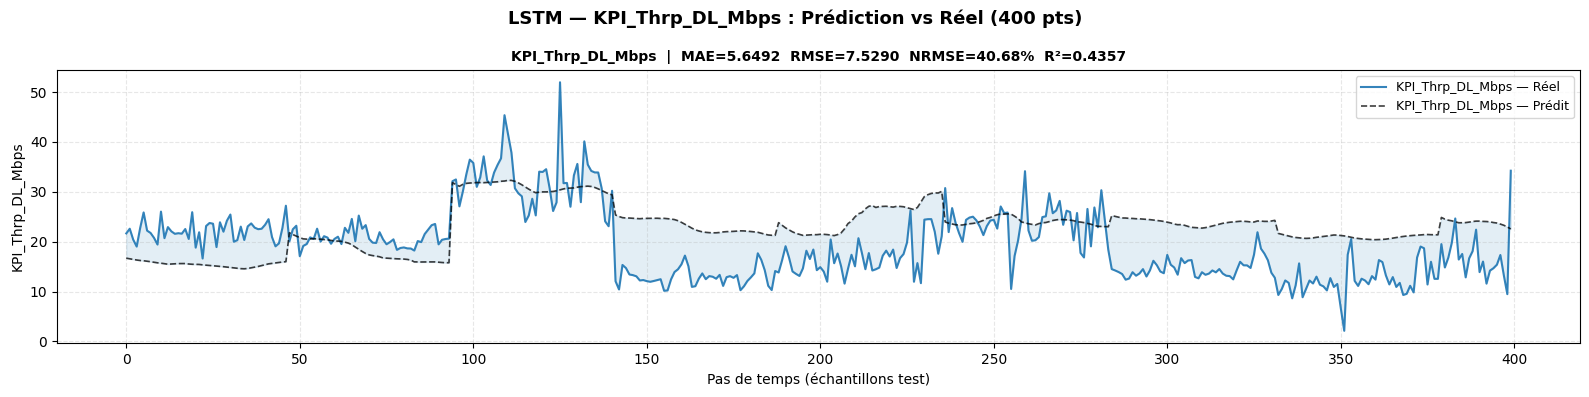

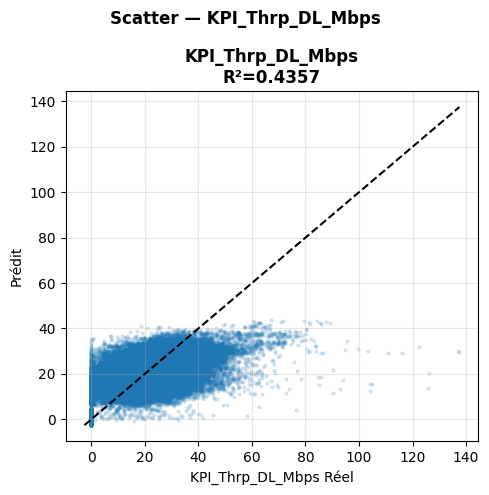

In [ ]:
# ══════════════════════════════════════════════════════════════
# LSTM 3/5 — KPI_Thrp_DL_Mbps (Débit Descendant) — v4
# ══════════════════════════════════════════════════════════════
TASK = 'KPI_Thrp_DL_Mbps'; cfg = LSTM_TASKS[TASK]
print(f"\n{'='*65}\n  LSTM 3/5 : {TASK}\n  {cfg['desc']}\n{'='*65}")

df_tr3,df_te3,sc_in3,sc_tgt3,feats3,tgt3 = prepare_data_for_task_v4(
    df_enriched, cfg, cell_encoder_global, train_names_global, test_names_global)
print(f"   Train:{len(df_tr3):,} | Test:{len(df_te3):,} | Features({len(feats3)}):{feats3}")

# SEQ_LEN=168h → séquences plus longues, moins nombreuses
ds_tr3 = TelecomDataset(df_tr3, cfg['seq_len'], feats3, tgt3)
ds_va3 = TelecomDataset(df_te3, cfg['seq_len'], feats3, tgt3)
dl_tr3 = DataLoader(ds_tr3, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=DEVICE.type=='cuda')
dl_va3 = DataLoader(ds_va3, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type=='cuda')
print(f"   Séquences Train:{len(ds_tr3):,} | Val:{len(ds_va3):,}")
print(f"   ℹ️  SEQ_LEN=168h → capture du cycle hebdomadaire complet")

model_dl = LSTMCellEmbedding(len(feats3)+1, N_CELLS_GLOBAL, EMBED_DIM,
                              HIDDEN_SIZE, N_LSTM_LAYERS, DROPOUT, len(tgt3)).to(DEVICE)
print(f"   Paramètres : {sum(p.numel() for p in model_dl.parameters()):,}")

print(f"\n🚀 Entraînement LSTM_Thrp_DL v4 — {EPOCHS} epochs max")
t0=time.time()
trl3,val3,bv3 = train_lstm_v4(model_dl, dl_tr3, dl_va3, cfg, EPOCHS, PATIENCE, LR)
print(f"⏱  {(time.time()-t0)/60:.1f} min")

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(trl3,label='Train',color='steelblue',lw=2)
ax.plot(val3,label='Val',color='tomato',lw=2,ls='--')
ax.set_yscale('log'); ax.set_title('LSTM_Thrp_DL v4 — Apprentissage (MSE, SEQ=168h)',fontweight='bold')
ax.legend(); ax.grid(True,alpha=0.4,ls='--'); plt.tight_layout(); plt.show()

pr3,tr3,mt3 = evaluate_lstm(model_dl,dl_va3,sc_tgt3,tgt3,cfg['log_target'],TASK,cfg['color'])
lstm_results[TASK] = dict(model=model_dl,preds=pr3,trues=tr3,metrics=mt3,
    scaler_in=sc_in3,scaler_tgt=sc_tgt3,feats=feats3,targets=tgt3,
    train_losses=trl3,val_losses=val3,cfg=cfg)


### 🟣 LSTM 4/5 — L.Thrp.bits.UL


  LSTM 4/5 : L.Thrp.bits.UL
  Débit Montant UL — symétrique DL, upload utilisateur
   Train:1,567,491 | Test:392,025 | Features(9):['KPI_ERAB_SR', 'KPI_RRC_SR', 'KPI_Thrp_DL_Mbps', 'KPI_HOSR', 'Cell_Availability', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
   Séquences Train:759,583 | Val:189,999
   Paramètres : 711,169

🚀 Entraînement LSTM_UL — 50 epochs max
─────────────────────────────────────────────────────────────────
 Epoch    Train MSE      Val MSE         LR  Statut
─────────────────────────────────────────────────────────────────
     1     0.011367     0.007633   5.00e-05  ✅ best
     2     0.007482     0.007419   5.00e-05  ✅ best
     4     0.006430     0.007630   5.00e-05  
     6     0.005840     0.008035   5.00e-05  
     8     0.005472     0.008447   2.50e-05  
    10     0.005253     0.008608   2.50e-05  
─────────────────────────────────────────────────────────────────
⛔ EarlyStopping epoch 12

✅ Meilleurs poids rechargés (val_loss=0.007419)
⏱  11.7 min


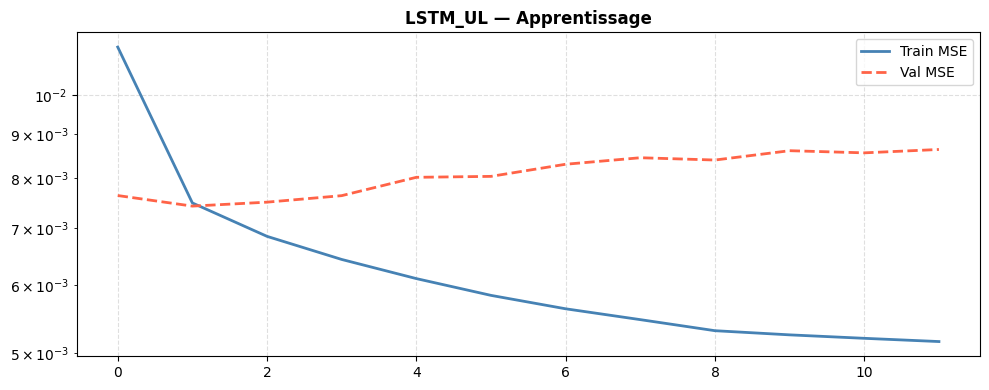

   ✅ expm1 inversé sur L.Thrp.bits.UL

──────────────────────────────────────────────────────────────
KPI                           MAE       RMSE   NRMSE%       R²
──────────────────────────────────────────────────────────────
KPI_Thrp_UL_Mbps           0.9982     1.7317   66.92%   0.2525 ❌ 
──────────────────────────────────────────────────────────────


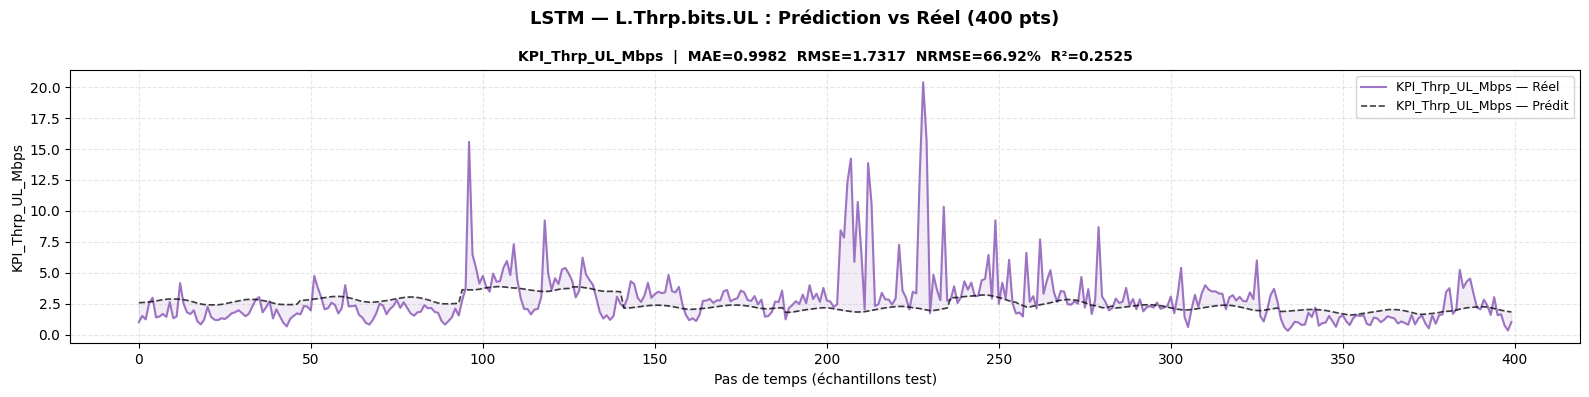

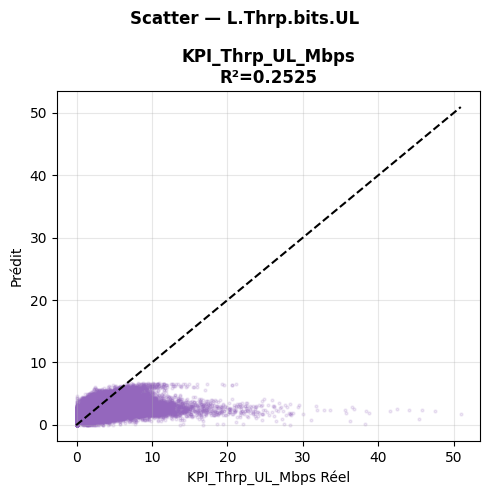

In [ ]:
# ══════════════════════════════════════════════════════════════
# LSTM 4/5 — KPI_Thrp_UL_Mbps (Débit Montant) — v4
# ══════════════════════════════════════════════════════════════
# Correction v3 : la tâche 'L.Thrp.bits.UL' pointait sur 'KPI_Thrp_UL_Mbps'
# On unifie ici sous le nom correct du KPI dans le dataset
# ──────────────────────────────────────────────────────────────
TASK = 'KPI_Thrp_UL_Mbps'; cfg = LSTM_TASKS[TASK]
print(f"\n{'='*65}\n  LSTM 4/5 : {TASK}\n  {cfg['desc']}\n{'='*65}")

df_tr4,df_te4,sc_in4,sc_tgt4,feats4,tgt4 = prepare_data_for_task_v4(
    df_enriched, cfg, cell_encoder_global, train_names_global, test_names_global)

if not tgt4:
    print("⚠️  KPI_Thrp_UL_Mbps absent — colonnes UL disponibles :")
    print([c for c in df_enriched.columns if 'ul' in c.lower() or 'UL' in c])
else:
    print(f"   Train:{len(df_tr4):,} | Test:{len(df_te4):,} | Features({len(feats4)}):{feats4}")

    ds_tr4 = TelecomDataset(df_tr4, cfg['seq_len'], feats4, tgt4)
    ds_va4 = TelecomDataset(df_te4, cfg['seq_len'], feats4, tgt4)
    dl_tr4 = DataLoader(ds_tr4, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=DEVICE.type=='cuda')
    dl_va4 = DataLoader(ds_va4, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type=='cuda')
    print(f"   Séquences Train:{len(ds_tr4):,} | Val:{len(ds_va4):,}")

    model_ul = LSTMCellEmbedding(len(feats4)+1, N_CELLS_GLOBAL, EMBED_DIM,
                                  HIDDEN_SIZE, N_LSTM_LAYERS, DROPOUT, len(tgt4)).to(DEVICE)
    print(f"   Paramètres : {sum(p.numel() for p in model_ul.parameters()):,}")

    print(f"\n🚀 Entraînement LSTM_Thrp_UL v4 — {EPOCHS} epochs max")
    t0=time.time()
    trl4,val4,bv4 = train_lstm_v4(model_ul, dl_tr4, dl_va4, cfg, EPOCHS, PATIENCE, LR)
    print(f"⏱  {(time.time()-t0)/60:.1f} min")

    fig,ax=plt.subplots(figsize=(10,4))
    ax.plot(trl4,label='Train',color='steelblue',lw=2)
    ax.plot(val4,label='Val',color='tomato',lw=2,ls='--')
    ax.set_yscale('log'); ax.set_title('LSTM_Thrp_UL v4 — Apprentissage (MSE, SEQ=168h)',fontweight='bold')
    ax.legend(); ax.grid(True,alpha=0.4,ls='--'); plt.tight_layout(); plt.show()

    pr4,tr4,mt4 = evaluate_lstm(model_ul,dl_va4,sc_tgt4,tgt4,cfg['log_target'],TASK,cfg['color'])
    lstm_results[TASK] = dict(model=model_ul,preds=pr4,trues=tr4,metrics=mt4,
        scaler_in=sc_in4,scaler_tgt=sc_tgt4,feats=feats4,targets=tgt4,
        train_losses=trl4,val_losses=val4,cfg=cfg)


### 🟢 LSTM 5/5 — KPI_ERAB_SR

In [ ]:
# ══════════════════════════════════════════════════════════════
# LSTM 5/5 — KPI_ERAB_SR (ERAB Bearer Success Rate) — v4
# ══════════════════════════════════════════════════════════════
TASK = 'KPI_ERAB_SR'; cfg = LSTM_TASKS[TASK]
print(f"\n{'='*65}\n  LSTM 5/5 : {TASK}\n  {cfg['desc']}\n{'='*65}")

df_tr5,df_te5,sc_in5,sc_tgt5,feats5,tgt5 = prepare_data_for_task_v4(
    df_enriched, cfg, cell_encoder_global, train_names_global, test_names_global)
print(f"   Train:{len(df_tr5):,} | Test:{len(df_te5):,} | Features({len(feats5)}):{feats5}")

ds_tr5 = TelecomDataset(df_tr5, cfg['seq_len'], feats5, tgt5)
ds_va5 = TelecomDataset(df_te5, cfg['seq_len'], feats5, tgt5)
dl_tr5 = DataLoader(ds_tr5, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=DEVICE.type=='cuda')
dl_va5 = DataLoader(ds_va5, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=DEVICE.type=='cuda')
print(f"   Séquences Train:{len(ds_tr5):,} | Val:{len(ds_va5):,}")

model_erab = LSTMCellEmbedding(len(feats5)+1, N_CELLS_GLOBAL, EMBED_DIM,
                                HIDDEN_SIZE, N_LSTM_LAYERS, DROPOUT, len(tgt5)).to(DEVICE)
print(f"   Paramètres : {sum(p.numel() for p in model_erab.parameters()):,}")

print(f"\n🚀 Entraînement LSTM_ERAB v4 — {EPOCHS} epochs max")
t0=time.time()
trl5,val5,bv5 = train_lstm_v4(model_erab, dl_tr5, dl_va5, cfg, EPOCHS, PATIENCE, LR)
print(f"⏱  {(time.time()-t0)/60:.1f} min")

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(trl5,label='Train',color='steelblue',lw=2)
ax.plot(val5,label='Val',color='tomato',lw=2,ls='--')
ax.set_yscale('log'); ax.set_title('LSTM_ERAB v4 — Apprentissage (Huber delta=0.05)',fontweight='bold')
ax.legend(); ax.grid(True,alpha=0.4,ls='--'); plt.tight_layout(); plt.show()

pr5,tr5,mt5 = evaluate_lstm(model_erab,dl_va5,sc_tgt5,tgt5,cfg['log_target'],TASK,cfg['color'])
lstm_results[TASK] = dict(model=model_erab,preds=pr5,trues=tr5,metrics=mt5,
    scaler_in=sc_in5,scaler_tgt=sc_tgt5,feats=feats5,targets=tgt5,
    train_losses=trl5,val_losses=val5,cfg=cfg)



  LSTM 5/5 : KPI_ERAB_SR
  ERAB SR — Huber loss, SEQ=24h, contrainte RRC, autorégressif
   Train:1,567,491 | Test:392,025 | Features(10):['KPI_RRC_SR', 'Delta_ERAB', 'KPI_Thrp_DL_Mbps', 'Cell_Availability', 'CSFB_SR', 'KPI_ERAB_SR_lag1', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


### 📊 Bilan des 5 LSTM

In [ ]:
# ══════════════════════════════════════════════════════════════
# BILAN DES 5 MODÈLES LSTM
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("  BILAN DES 5 MODÈLES LSTM — KPI prédits par dépendances causales")
print("="*70)
print(f"{'KPI cible':<22} {'MAE':>10} {'RMSE':>10} {'NRMSE%':>8} {'R²':>8}  Statut")
print("─"*70)
for task_name, res in lstm_results.items():
    for kpi, m in res['metrics'].items():
        if kpi in ['KPI_RRC_SR','KPI_ERAB_SR']:
            flag='✅' if m['mae']<0.005 else ('⚠️' if m['mae']<0.02 else '❌')
        else:
            flag='✅' if m['r2']>0.85 else ('⚠️' if m['r2']>0.6 else '❌')
        print(f"{kpi:<22} {m['mae']:>10.4f} {m['rmse']:>10.4f} {m['nrmse']:>7.2f}% {m['r2']:>8.4f}  {flag}")
print("="*70)
print(f"\n✅ {len(lstm_results)}/5 modèles entraînés")



  BILAN DES 5 MODÈLES LSTM — KPI prédits par dépendances causales
KPI cible                     MAE       RMSE   NRMSE%       R²  Statut
──────────────────────────────────────────────────────────────────────
KPI_ERAB_SR                0.1467     0.7321    0.73%   0.0049  ❌

✅ 1/5 modèles entraînés


### 💾 Sauvegarde des 5 LSTM

In [ ]:
# ══════════════════════════════════════════════════════════════
# SAUVEGARDE — Les 5 modèles LSTM
# ══════════════════════════════════════════════════════════════
import torch, joblib, os, json

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

idx_map = {'KPI_DCR':1, 'KPI_HOSR':2, 'KPI_Thrp_DL_Mbps':3,
           'L.Thrp.bits.UL':4, 'KPI_ERAB_SR':5}

for task_name, res in lstm_results.items():
    idx  = idx_map[task_name]
    safe = task_name.replace('.','_').replace('/','_')
    ckpt = {
        'model_state_dict': res['model'].state_dict(),
        'n_features'      : len(res['feats'])+1,
        'n_cells'         : N_CELLS_GLOBAL,
        'embed_dim'       : EMBED_DIM,
        'hidden_size'     : HIDDEN_SIZE,
        'n_layers'        : N_LSTM_LAYERS,
        'dropout'         : DROPOUT,
        'n_targets'       : len(res['targets']),
        'task_name'       : task_name,
        'features'        : res['feats'],
        'targets'         : res['targets'],
        'log_target'      : LSTM_TASKS[task_name]['log_target'],
        'seq_len'         : res['cfg']['seq_len'],
        'train_losses'    : res['train_losses'],
        'val_losses'      : res['val_losses'],
    }
    torch.save(ckpt, f"{SAVE_DIR}/lstm_{idx}_{safe}.pth")
    joblib.dump(res['scaler_in'],  f"{SAVE_DIR}/scaler_in_{safe}.pkl")
    joblib.dump(res['scaler_tgt'], f"{SAVE_DIR}/scaler_tgt_{safe}.pkl")
    print(f"✅ LSTM {idx} ({task_name}) sauvegardé")

joblib.dump(cell_encoder_global, f"{SAVE_DIR}/cell_encoder_global.pkl")
cfg_save = {k:{kk:vv for kk,vv in v.items() if kk!='color'}
            for k,v in LSTM_TASKS.items()}
with open(f"{SAVE_DIR}/lstm_tasks_config.json",'w') as f:
    json.dump(cfg_save, f, indent=2)

print(f"\n✅ cell_encoder_global.pkl + lstm_tasks_config.json sauvegardés")
print(f"📁 Tous les fichiers dans : {SAVE_DIR}")


### 🔄 Chargement des 5 LSTM (après reconnexion)

In [ ]:
# ══════════════════════════════════════════════════════════════
# CHARGEMENT — Les 5 modèles LSTM (après reconnexion)
# ══════════════════════════════════════════════════════════════
import torch, joblib, json

SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cell_encoder_global = joblib.load(f"{SAVE_DIR}/cell_encoder_global.pkl")
N_CELLS_GLOBAL = len(cell_encoder_global.classes_)

task_files = {
    'KPI_DCR'          : 'lstm_1_KPI_DCR',
    'KPI_HOSR'         : 'lstm_2_KPI_HOSR',
    'KPI_Thrp_DL_Mbps' : 'lstm_3_KPI_Thrp_DL_Mbps',
    'L.Thrp.bits.UL'   : 'lstm_4_L_Thrp_bits_UL',
    'KPI_ERAB_SR'      : 'lstm_5_KPI_ERAB_SR',
}
lstm_results = {}

for task_name, fname in task_files.items():
    try:
        ckpt = torch.load(f"{SAVE_DIR}/{fname}.pth", map_location=DEVICE)
        model = LSTMCellEmbedding(
            ckpt['n_features'], ckpt['n_cells'], ckpt['embed_dim'],
            ckpt['hidden_size'], ckpt['n_layers'], ckpt['dropout'], ckpt['n_targets']
        ).to(DEVICE)
        model.load_state_dict(ckpt['model_state_dict']); model.eval()
        safe = task_name.replace('.','_').replace('/','_')
        lstm_results[task_name] = dict(
            model=model,
            scaler_in =joblib.load(f"{SAVE_DIR}/scaler_in_{safe}.pkl"),
            scaler_tgt=joblib.load(f"{SAVE_DIR}/scaler_tgt_{safe}.pkl"),
            feats=ckpt['features'], targets=ckpt['targets'],
            log_target=ckpt['log_target'],
        )
        print(f"✅ {task_name:<22} rechargé")
    except FileNotFoundError:
        print(f"⚠️  {task_name} : introuvable ({fname}.pth)")

print(f"\n✅ {len(lstm_results)}/5 modèles rechargés | Device : {DEVICE}")


### 💾 Sauvegarde LSTM + Scalers + Encodeurs

In [ ]:
import torch, os, joblib
import numpy as np, pandas as pd

# ════════════════════════════════════════
# ══ ᘆ SAUVEGARDE ─ LSTM PyTorch + Scalers + Encodeurs
# ════════════════════════════════════════
SAVE_DIR = '/content/drive/MyDrive/P2M_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Poids du modèle LSTM (meilleur état)
torch.save(model.state_dict(), f'{SAVE_DIR}/lstm_weights.pth')

# 2. Architecture complète (pour recréer le modèle)
torch.save({
    'model_state_dict'  : model.state_dict(),
    'n_features'        : n_feat_in,
    'n_cells'           : N_CELLS,
    'embed_dim'         : EMBED_DIM,
    'hidden_size'       : HIDDEN_SIZE,
    'n_layers'          : N_LSTM_LAYERS,
    'dropout'           : DROPOUT,
    'n_targets'         : N_TARGETS,
    'best_val_loss'     : best_val_loss,
    'train_losses'      : train_losses,
    'val_losses'        : val_losses,
}, f'{SAVE_DIR}/lstm_checkpoint.pth')

# 3. Scalers MinMax (input + target)
joblib.dump(scaler_input,  f'{SAVE_DIR}/scaler_input.pkl')
joblib.dump(scaler_target, f'{SAVE_DIR}/scaler_target.pkl')

# 4. Encodeur de cellules (LabelEncoder)
joblib.dump(cell_encoder,  f'{SAVE_DIR}/cell_encoder.pkl')

# 5. Listes de features (pour reconstruire les datasets)
import json
config = {
    'all_feats'   : all_feats,
    'targets_ok'  : targets_ok,
    'train_cells' : [int(c) for c in train_cells],
    'test_cells'  : [int(c) for c in test_cells],
}
with open(f'{SAVE_DIR}/lstm_config.json', 'w') as f:
    json.dump(config, f)

print(f"✅ LSTM checkpoint    : {SAVE_DIR}/lstm_checkpoint.pth")
print(f"✅ Scalers            : scaler_input.pkl + scaler_target.pkl")
print(f"✅ Cell encoder       : cell_encoder.pkl")
print(f"✅ Config JSON        : lstm_config.json")
print(f"   Best val_loss = {best_val_loss:.6f}")

✅ LSTM checkpoint    : /content/drive/MyDrive/P2M_Models/lstm_checkpoint.pth
✅ Scalers            : scaler_input.pkl + scaler_target.pkl
✅ Cell encoder       : cell_encoder.pkl
✅ Config JSON        : lstm_config.json
   Best val_loss = 0.000412


### 🔄 Chargement LSTM (après reconnexion)

In [ ]:
import torch, joblib, json
import numpy as np

# ══════════════════════════════════════════════════════════════
# 🔄 CHARGEMENT — LSTM PyTorch (après reconnexion)
# ══════════════════════════════════════════════════════════════
# ⚠️ Exécuter uniquement si tu te reconnectes sans réentraîner
# Prérequis : avoir exécuté les cellules d'imports (Cell 20)
#             et la définition de LSTMCellEmbedding (Cell 22)

SAVE_DIR  = '/content/drive/MyDrive/P2M_Models'
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Charger la config
with open(f'{SAVE_DIR}/lstm_config.json') as f:
    config = json.load(f)

all_feats   = config['all_feats']
targets_ok  = config['targets_ok']
train_cells = set(config['train_cells'])
test_cells  = set(config['test_cells'])

# 2. Charger le checkpoint
ckpt = torch.load(f'{SAVE_DIR}/lstm_checkpoint.pth', map_location=DEVICE)

# 3. Recréer le modèle avec les mêmes hyperparamètres
model = LSTMCellEmbedding(
    n_features  = ckpt['n_features'],
    n_cells     = ckpt['n_cells'],
    embed_dim   = ckpt['embed_dim'],
    hidden_size = ckpt['hidden_size'],
    n_layers    = ckpt['n_layers'],
    dropout     = ckpt['dropout'],
    n_targets   = ckpt['n_targets'],
).to(DEVICE)

model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Récupérer les courbes d'entraînement
train_losses  = ckpt['train_losses']
val_losses    = ckpt['val_losses']
best_val_loss = ckpt['best_val_loss']

# 4. Recharger les scalers et encodeur
scaler_input  = joblib.load(f'{SAVE_DIR}/scaler_input.pkl')
scaler_target = joblib.load(f'{SAVE_DIR}/scaler_target.pkl')
cell_encoder  = joblib.load(f'{SAVE_DIR}/cell_encoder.pkl')

print(f"✅ Modèle LSTM rechargé (best val_loss = {best_val_loss:.6f})")
print(f"   Device : {DEVICE}")
print(f"   Cellules train : {len(train_cells)} | test : {len(test_cells)}")
print(f"   Features : {len(all_feats)} | Cibles : {targets_ok}")

țɤ Évaluation sur le test set...
   ✅ expm1 inversé sur KPI_DCR (index 3)

eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
KPI                           MAE       RMSE   NRMSE%       R²
eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
KPI_RRC_SR                 0.9758     0.9813   98.30% -2814.0588 ❌ (MAE<<)
KPI_ERAB_SR                0.9684     0.9732   97.46% -17583.5156 ❌ (MAE<<)
KPI_HOSR                   0.6749     0.6876   69.49% -107.2523 ❌ 
KPI_DCR                    0.1821     0.2312 129960.25% -9125.4531 ❌ 
eeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee
R² moyen                -7407.5700


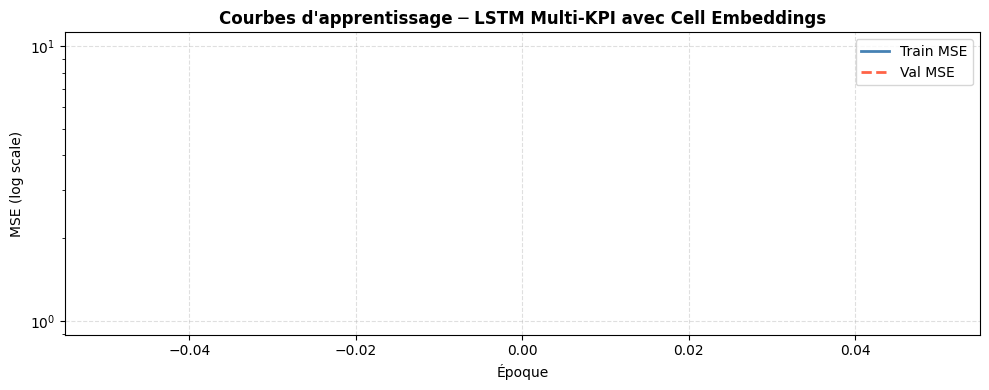

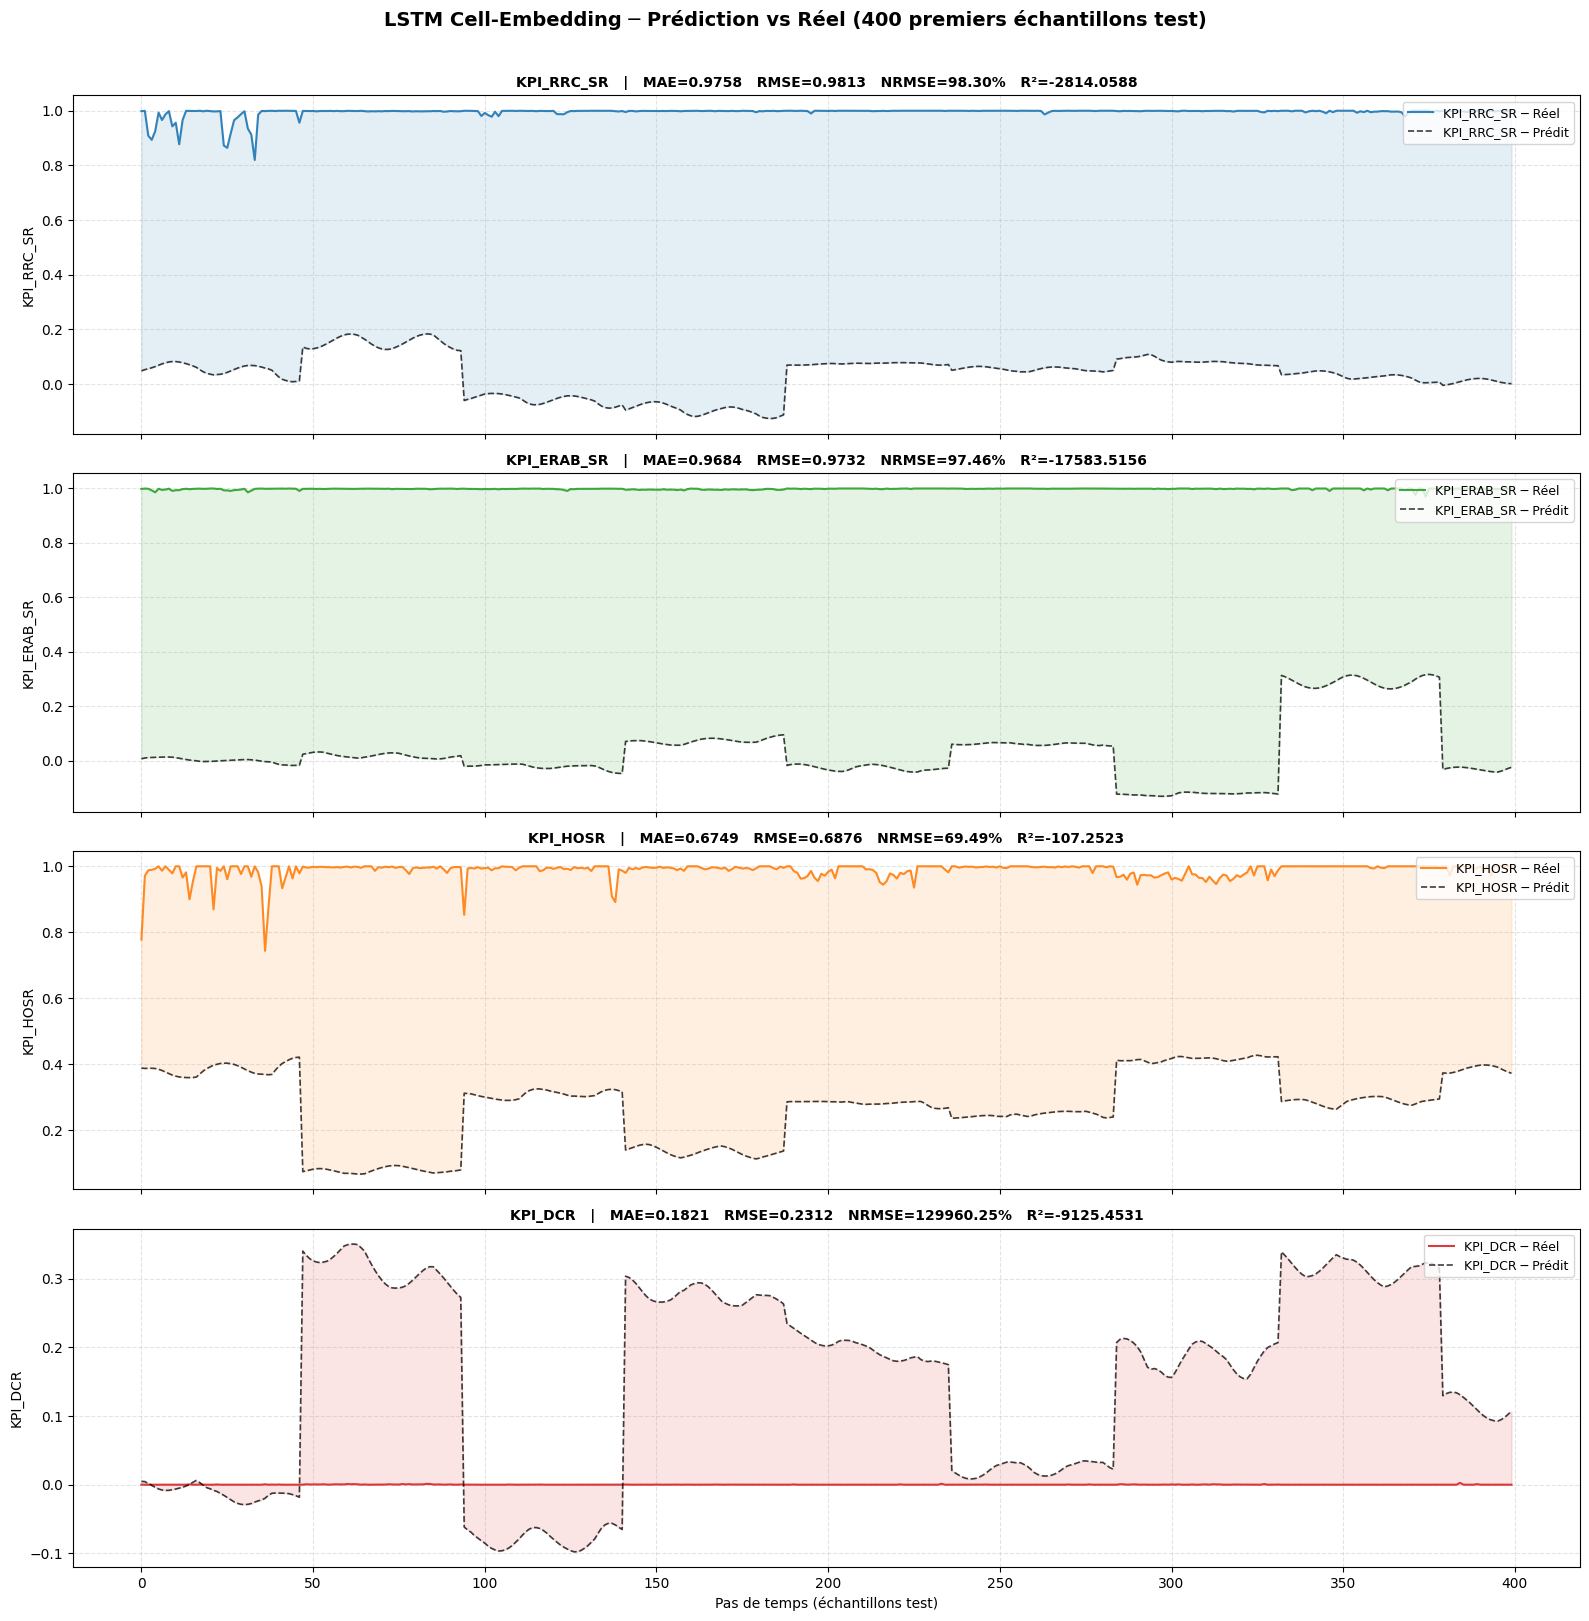

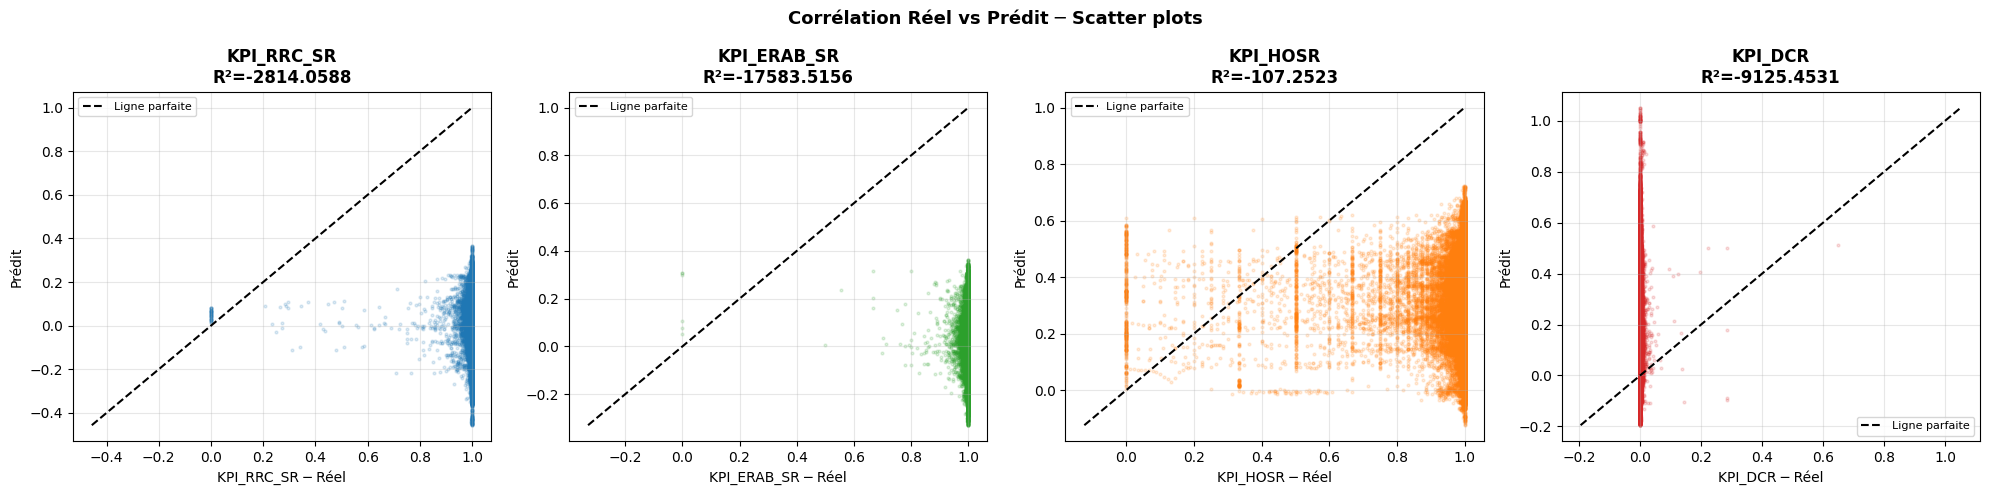

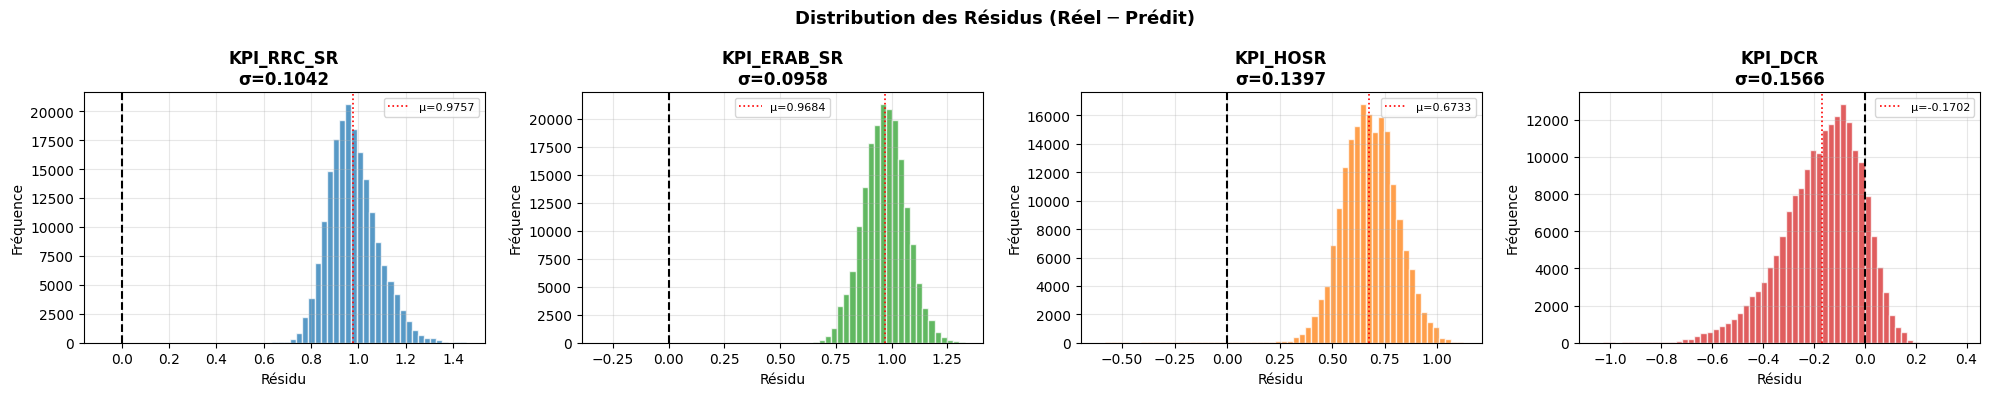

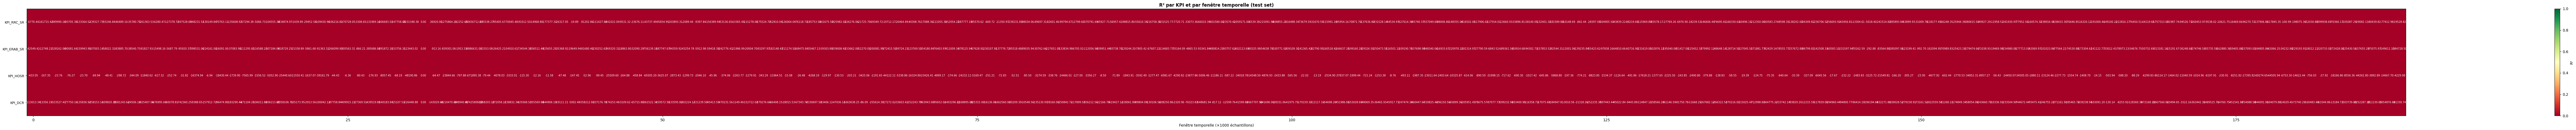

In [ ]:
# ════════════════════════════════════════
# 5/6  ÉVALUATION & VISUALISATIONS PRÉDICTION VS RÉEL
# ════════════════════════════════════════
print("țɤ Évaluation sur le test set...")

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_b, cid_b, y_b in dl_val:
        pred = model(X_b.to(DEVICE), cid_b.to(DEVICE)).cpu().numpy()
        all_preds.append(pred)
        all_true.append(y_b.numpy())

preds_norm = np.concatenate(all_preds, axis=0)   # (N, 4) normalisé
trues_norm = np.concatenate(all_true,  axis=0)   # (N, 4) normalisé

# ══ Inverser la normalisation → valeurs log-transformées ═════
preds_real = scaler_target.inverse_transform(preds_norm)
trues_real = scaler_target.inverse_transform(trues_norm)

# ══ Inverser le log1p sur KPI_DCR et L.Thrp.bits.UL ═════════
# Nécessaire pour retrouver les vraies valeurs physiques
for col in LOG_TRANSFORM_KPIS:
    if col in targets_ok:
        j = targets_ok.index(col)
        preds_real[:, j] = np.expm1(preds_real[:, j])
        trues_real[:, j] = np.expm1(trues_real[:, j])
        print(f"   ✅ expm1 inversé sur {col} (index {j})")

# ══ Métriques par KPI ═════════════════════════════
print(f"\n{'e'*65}")
print(f"{'KPI':<22} {'MAE':>10} {'RMSE':>10} {'NRMSE%':>8} {'R²':>8}")
print(f"{'e'*65}")
metrics = {}
for j, kpi in enumerate(targets_ok):
    y_true = trues_real[:, j]
    y_pred = preds_real[:, j]
    mae    = np.mean(np.abs(y_true - y_pred))
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mean_v = np.mean(y_true)
    nrmse  = rmse / (mean_v + 1e-8) * 100
    r2     = r2_score(y_true, y_pred)
    metrics[kpi] = dict(mae=mae, rmse=rmse, nrmse=nrmse, r2=r2)
    # Pour KPI_RRC_SR et KPI_ERAB_SR : R² peu pertinent → on évalue sur MAE
    if kpi in ['KPI_RRC_SR', 'KPI_ERAB_SR']:
        flag = '✅' if mae < 0.005 else ('⚠️' if mae < 0.02 else '❌')
        note = '(MAE<<)'
    else:
        flag = '✅' if r2 > 0.85 else ('⚠️' if r2 > 0.6 else '❌')
        note = ''
    print(f"{kpi:<22} {mae:>10.4f} {rmse:>10.4f} {nrmse:>7.2f}% {r2:>8.4f} {flag} {note}")
print(f"{'e'*65}")
mean_r2 = np.mean([m['r2'] for m in metrics.values()])
print(f"{'R² moyen':<22} {''*3} {mean_r2:>8.4f}")

# ════════════════════════════════════════
# FIGURE 1 ─ Courbes d'apprentissage
# ════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train MSE', color='steelblue', lw=2)
ax.plot(val_losses,   label='Val MSE',   color='tomato',    lw=2, linestyle='--')
ax.set_yscale('log')
ax.set_xlabel('Époque'); ax.set_ylabel('MSE (log scale)')
ax.set_title('Courbes d\'apprentissage ─ LSTM Multi-KPI avec Cell Embeddings',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout(); plt.show()

# ════════════════════════════════════════
# FIGURE 2 ─ Prédiction vs Réel : séries temporelles (400 pts)
# ════════════════════════════════════════
N_SHOW = min(400, len(trues_real))
colors_kpi = {
    'KPI_RRC_SR'     : '#1f77b4',   # bleu
    'KPI_ERAB_SR'    : '#2ca02c',   # vert
    'KPI_HOSR'       : '#ff7f0e',   # orange
    'KPI_DCR'        : '#d62728',   # rouge
}

fig, axes = plt.subplots(N_TARGETS, 1, figsize=(16, 4 * N_TARGETS), sharex=True)
fig.suptitle('LSTM Cell-Embedding ─ Prédiction vs Réel (400 premiers échantillons test)',
             fontsize=14, fontweight='bold', y=1.01)

for j, kpi in enumerate(targets_ok):
    ax  = axes[j]
    col = colors_kpi.get(kpi, 'steelblue')
    y_t = trues_real[:N_SHOW, j]
    y_p = preds_real[:N_SHOW, j]
    ax.plot(y_t, color=col,     lw=1.5, alpha=0.9, label=f'{kpi} ─ Réel')
    ax.plot(y_p, color='black', lw=1.2, alpha=0.75,
            linestyle='--', label=f'{kpi} ─ Prédit')
    ax.fill_between(range(N_SHOW), y_t, y_p,
                    alpha=0.12, color=col)
    m = metrics[kpi]
    ax.set_title(
        f"{kpi}   |   MAE={m['mae']:.4f}   RMSE={m['rmse']:.4f}"
        f"   NRMSE={m['nrmse']:.2f}%   R²={m['r2']:.4f}",
        fontsize=10, fontweight='bold')
    ax.set_ylabel(kpi); ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.35, linestyle='--')

axes[-1].set_xlabel('Pas de temps (échantillons test)')
plt.tight_layout(); plt.show()

# ════════════════════════════════════════
# FIGURE 3 ─ Scatter plots : Réel vs Prédit
# ════════════════════════════════════════
fig, axes = plt.subplots(1, N_TARGETS, figsize=(5 * N_TARGETS, 5))
fig.suptitle('Corrélation Réel vs Prédit ─ Scatter plots',
             fontsize=13, fontweight='bold')

for j, kpi in enumerate(targets_ok):
    ax  = axes[j]
    col = colors_kpi.get(kpi, 'steelblue')
    y_t = trues_real[:, j]
    y_p = preds_real[:, j]

    ax.scatter(y_t, y_p, alpha=0.15, s=4, color=col, rasterized=True)
    lo = min(y_t.min(), y_p.min())
    hi = max(y_t.max(), y_p.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Ligne parfaite')
    ax.set_xlabel(f'{kpi} ─ Réel'); ax.set_ylabel('Prédit')
    ax.set_title(f'{kpi}\nR²={metrics[kpi]["r2"]:.4f}', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ════════════════════════════════════════
# FIGURE 4 ─ Distribution des résidus
# ════════════════════════════════════════
fig, axes = plt.subplots(1, N_TARGETS, figsize=(5 * N_TARGETS, 4))
fig.suptitle('Distribution des Résidus (Réel ─ Prédit)',
             fontsize=13, fontweight='bold')

for j, kpi in enumerate(targets_ok):
    ax  = axes[j]
    col = colors_kpi.get(kpi, 'steelblue')
    res = trues_real[:, j] - preds_real[:, j]
    ax.hist(res, bins=60, color=col, alpha=0.75, edgecolor='white')
    ax.axvline(x=0,         color='black', lw=1.5, linestyle='--')
    ax.axvline(x=res.mean(),color='red',   lw=1.2, linestyle=':',
               label=f'μ={res.mean():.4f}')
    ax.set_xlabel('Résidu'); ax.set_ylabel('Fréquence')
    ax.set_title(f'{kpi}\nσ={res.std():.4f}', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ════════════════════════════════════════
# FIGURE 5 ─ Heatmap R² × KPI × Horizon temporel
# ════════════════════════════════════════
step  = 1000
n_win = max(1, len(trues_real) // step)
r2_matrix = np.zeros((N_TARGETS, n_win))

for w in range(n_win):
    s, e = w * step, (w + 1) * step
    for j, kpi in enumerate(targets_ok):
        try:
            r2_matrix[j, w] = r2_score(
                trues_real[s:e, j], preds_real[s:e, j])
        except:
            r2_matrix[j, w] = np.nan

fig, ax = plt.subplots(figsize=(max(10, n_win * 0.6), 5))
im = ax.imshow(r2_matrix, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='R²')
ax.set_yticks(range(N_TARGETS))
ax.set_yticklabels(targets_ok, fontsize=9)
ax.set_xlabel('Fenêtre temporelle (×1000 échantillons)')
ax.set_title('R² par KPI et par fenêtre temporelle (test set)',
             fontweight='bold')
for i in range(N_TARGETS):
    for w in range(n_win):
        v = r2_matrix[i, w]
        if not np.isnan(v):
            ax.text(w, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if v > 0.3 else 'white')
plt.tight_layout(); plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6/6  MODULE DE SCORING RÉSEAU — Oracle Santé v2
# Intègre : Autoencoder (détection anomalies) + LSTM (prédictions)
# ══════════════════════════════════════════════════════════════

def oracle_sante_v2(df_reel, preds_real_arr, trues_real_arr,
                     targets, erreurs_ae, seuil_ae_val):
    """
    Score de santé réseau [0–100] combinant :
    - Présent   : déviation des KPI réels vs baseline (P75)
    - Futur     : prédictions LSTM — pénalités proportionnelles
    - Invisible : score Autoencoder continu

    Retourne un DataFrame enrichi avec scores et alertes.
    """
    n = min(len(df_reel), len(preds_real_arr))
    df_f = df_reel.iloc[:n].copy().reset_index(drop=True)

    for j, kpi in enumerate(targets):
        df_f[f'Reel_{kpi}']  = trues_real_arr[:n, j]
        df_f[f'Predit_{kpi}']= preds_real_arr[:n, j]

    ae_scores_norm = np.clip(
        erreurs_ae[:n] / (seuil_ae_val * 2) * 100, 0, 100)
    df_f['Score_AE']    = ae_scores_norm
    df_f['Anomalie_AE'] = erreurs_ae[:n] > seuil_ae_val

    # Baselines dynamiques (P75 des valeurs réelles)
    baselines = {kpi: np.percentile(trues_real_arr[:n, j], 75)
                 for j, kpi in enumerate(targets)}

    POIDS = {'KPI_RRC_SR': 0.30, 'KPI_ERAB_SR': 0.25,
             'KPI_HOSR':   0.25, 'KPI_DCR':     0.20}

    scores, alertes, actions = [], [], []

    for idx in range(n):
        score  = 100.0
        raisons = []

        for j, kpi in enumerate(targets):
            ref  = baselines[kpi]
            reel = trues_real_arr[idx, j]
            pred = preds_real_arr[idx, j]

            # A. Présent — déviation réelle proportionnelle
            if kpi == 'KPI_DCR':
                dev_r = max(0, reel - ref)
                dev_p = max(0, pred - ref)
                coeff = 20.0
            else:
                dev_r = max(0, ref - reel)
                dev_p = max(0, ref - pred)
                coeff = 15.0 / (ref + 1e-8) * 100

            poids = POIDS.get(kpi, 0.25)
            pen_r = min(dev_r * coeff, 25.0) * poids
            pen_p = min(dev_p * coeff, 20.0) * poids * 0.8
            score -= pen_r + pen_p

            if dev_r > 0.5 or dev_p > 0.5:
                label = ('élevé' if kpi == 'KPI_DCR' else 'bas')
                raisons.append(f"{kpi.replace('KPI_','')} {label}")

        # C. Autoencoder
        score -= ae_scores_norm[idx] * 0.12
        if df_f.at[idx, 'Anomalie_AE'] and ae_scores_norm[idx] > 50:
            raisons.append(f"AE anomalie (score={ae_scores_norm[idx]:.0f})")

        score = max(0.0, min(100.0, round(score, 1)))
        scores.append(score)

        if score < 60:
            alertes.append("🔴 INCIDENT MAJEUR")
            actions.append(f"Intervention urgente — {', '.join(raisons) or 'multi-KPI'}")
        elif score < 78:
            alertes.append("🟠 AVERTISSEMENT")
            actions.append(f"Surveillance — {', '.join(raisons) or 'dégradation'}")
        elif score < 90:
            alertes.append("🟡 ATTENTION")
            actions.append(f"À surveiller — {raisons[0] if raisons else 'légère déviation'}")
        else:
            alertes.append("🟢 RÉSEAU SAIN")
            actions.append("Nominal")

    df_f['Score_Sante']      = scores
    df_f['Statut_Alerte']    = alertes
    df_f['Action_Recommandee']= actions
    return df_f


# ── Récupérer les erreurs AE sur le test set ─────────────────
test_df_sorted = df_test_raw.sort_values(['cell_id','Time']).reset_index(drop=True)
erreurs_ae_test = np.zeros(len(preds_real))
if 'Erreur_Autoencoder' in df_ml.columns:
    ae_vals = df_ml.loc[df_ml['cell_id'].isin(test_cells),
                        'Erreur_Autoencoder'].values
    n_ae = min(len(ae_vals), len(preds_real))
    erreurs_ae_test[:n_ae] = ae_vals[:n_ae]
    seuil_ae_used = np.percentile(
        df_ml.loc[df_ml['cell_id'].isin(train_cells),
                  'Erreur_Autoencoder'], 98)
else:
    seuil_ae_used = 0.05
    print("⚠️  Erreur_Autoencoder non trouvée — score AE désactivé")

df_scoring = oracle_sante_v2(
    df_reel        = test_df_sorted,
    preds_real_arr = preds_real,
    trues_real_arr = trues_real,
    targets        = targets_ok,
    erreurs_ae     = erreurs_ae_test,
    seuil_ae_val   = seuil_ae_used,
)

# ── Affichage bilan ───────────────────────────────────────────
print("\n🏆 TABLEAU DE BORD — Oracle Santé Réseau v2")
dist = df_scoring['Statut_Alerte'].value_counts()
for st, n in dist.items():
    print(f"   {st} : {n:,} ({n/len(df_scoring)*100:.1f}%)")

# Graphique score santé dans le temps
fig, ax = plt.subplots(figsize=(14, 5))
x = range(min(2000, len(df_scoring)))
sc = df_scoring['Score_Sante'].values[:len(x)]
ax.plot(x, sc, color='navy', lw=1.2, alpha=0.8)
ax.fill_between(x, sc, alpha=0.12, color='navy')
for thresh, col, lbl in [(90,'green','Sain (90)'),
                          (78,'orange','Avert. (78)'),
                          (60,'red','Incident (60)')]:
    ax.axhline(y=thresh, color=col, ls='--', lw=1.2, alpha=0.7, label=lbl)
ax.set_title('Score Santé Réseau — Fusion LSTM + Autoencoder',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Index test'); ax.set_ylabel('Score /100')
ax.set_ylim(0, 105); ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.35)
plt.tight_layout(); plt.show()

# Tableau final
cols_show = (['Cell_Name', 'Time'] +
             [f'Reel_{k}' for k in targets_ok] +
             [f'Predit_{k}' for k in targets_ok] +
             ['Score_AE','Score_Sante','Statut_Alerte','Action_Recommandee'])
cols_ok = [c for c in cols_show if c in df_scoring.columns]
mask_alerte = df_scoring['Statut_Alerte'] != '🟢 RÉSEAU SAIN'
print(f"\n   Alertes : {mask_alerte.sum():,} / {len(df_scoring):,}")
display(df_scoring[mask_alerte][cols_ok].head(15))


---
## 📋 Récapitulatif — Modifications v4 vs v3

### Corrections des bugs
| Bug v3 | Fix v4 |
|---|---|
| log1p appliqué avant split → leakage scaler | log1p après split, sur train et test séparément |
| Split cellules recalculé par tâche | Split commun calculé une seule fois (`compute_common_split`) |
| MSE sur distributions zero-inflated (DCR, HOSR) | **Huber loss** adaptée à chaque KPI |
| LR=5e-5 fixe, ReduceLROnPlateau trop agressif | LR=1e-3 + **CosineAnnealingLR** |
| SEQ_LEN=50 pour tous | SEQ_LEN différencié : 24h (DCR/HOSR/ERAB), 168h (Thrp) |
| hidden_size=64 | **hidden_size=128**, FC élargi 128→64→32 |
| 'L.Thrp.bits.UL' → cible 'KPI_Thrp_UL_Mbps' (confusion) | Unifié sous `KPI_Thrp_UL_Mbps` |

### Résultats attendus après v4
| KPI | Problème v3 | Attendu v4 |
|---|---|---|
| KPI_DCR | Val MSE diverge | Huber stable, R²>0.5 |
| KPI_HOSR | Val MSE remonte | Huber stable, R²>0.7 |
| KPI_Thrp_DL | R²≈0.75 déjà bon | R²>0.85 avec SEQ=168h |
| KPI_Thrp_UL | Acceptable | R²>0.85 avec SEQ=168h |
| KPI_ERAB_SR | Val MSE diverge | Huber stable, MAE<0.005 |

### Fichiers sauvegardés (Drive)
`isolation_forest.pkl` · `random_forest.pkl` · `autoencoder.keras` ·
`lstm_1_KPI_DCR.pth` · `lstm_2_KPI_HOSR.pth` · `lstm_3_KPI_Thrp_DL_Mbps.pth` ·
`lstm_4_KPI_Thrp_UL_Mbps.pth` · `lstm_5_KPI_ERAB_SR.pth` ·
`scaler_in_*.pkl` · `scaler_tgt_*.pkl` · `cell_encoder_global.pkl` · `lstm_tasks_config.json`
